In [1]:
#Все необходимые библиотеки
import pandas as pd
import os
import numpy as np
import cv2
from PIL import Image
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torch as th

import torchvision
from torchvision import datasets, models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from skimage.io import imread
from torch.utils import data
from tqdm import tqdm

import glob
import re

import time

from sklearn.metrics import confusion_matrix
import seaborn as sns

from torchmetrics.classification import MulticlassSpecificity
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef

from torchvision.models import squeezenet1_1, SqueezeNet1_1_Weights
from torch.quantization import QuantStub, DeQuantStub, prepare_qat, prepare, convert, get_default_qconfig

model_name = 'squeezenet1_1'

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
original_NN = squeezenet1_1(weights=SqueezeNet1_1_Weights.IMAGENET1K_V1)
original_NN

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

In [21]:
class Multimodal_NN(nn.Module):
    def __init__(self, num_metadata_features, num_classes=10):
        super(Multimodal_NN, self).__init__()
        
        # Обычная AlexNet без QuantStub
        original_NN = squeezenet1_1(weights=SqueezeNet1_1_Weights.IMAGENET1K_V1)
        original_NN.classifier = nn.Identity()
        self.visual_features = original_NN
        
        self.visual_classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(86528, 512),
            nn.ReLU(inplace=True),
        )
        
        self.metadata_net = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(inplace=True),
        )
        
        combined_features = 512 + 16
        self.combined_classifier = nn.Sequential(
            nn.Linear(combined_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, image, metadata):
        visual_features = self.visual_features(image)
        visual_features = visual_features.reshape(visual_features.size(0), -1)
        visual_features = self.visual_classifier(visual_features)
        
        metadata_features = self.metadata_net(metadata)
        
        combined_features = torch.cat((visual_features, metadata_features), dim=1)
        output = self.combined_classifier(combined_features)
        return output

In [4]:
def test_NN(model, dataset):

    model = model.to(device)
    model.eval()
    
    with torch.no_grad():

        for data in dataset:
            image, feats, label, name = data
            image, feats, label = image.to(device), feats.to(device), label.to(device)

            output = model(image, feats)

            pred = (torch.max(torch.exp(output), 1)[1]).cpu().data.numpy()

            predictions.extend(pred)

            label = label.cpu().data.numpy()
            actuals.extend(label)
            
def test_metric():
    
    cm = confusion_matrix(actuals, predictions)
    FP = np.mean(cm.sum(axis=0) - np.diag(cm))  
    FN = np.mean(cm.sum(axis=1) - np.diag(cm))
    TP = np.mean(np.diag(cm))
    TN = np.mean(cm.sum() - (FP + FN + TP))

    Sensitivity = (TP/(TP+FN))
    Specificity = (TN/(TN+FP))
    Precision = (TP/(TP+FP))
    NPV = (TN/(TN+FN))
    PPV = (TP/(TP+FP))
    FNR = (FN/(FN+TP))
    FPR = (FP/(FP+TN))

    F1 = (2*TP)/((2*TP)+FP+FN)

    print('Sensitivity: %.4f' % Sensitivity)
    print('Specificity: %.4f' % Specificity)
    print('Precision: %.4f' % Precision)
    print('NPV: %.4f' % NPV)
    print('PPV: %.4f' % PPV)
    print('FNR: %.4f' % FNR)
    print('FPR: %.4f' % FPR)
    print('F1: %.4f' % F1)


    recall_1 = recall_score(actuals, predictions, average='micro')
    print('Recall micro: %.4f' % recall_1)
    recall_2 = recall_score(actuals, predictions, average='macro')
    print('Recall macro: %.4f' % recall_2)

    precision_1 = precision_score(actuals, predictions, average='micro')
    print('Precision micro: %.4f' % precision_1)
    precision_2 = precision_score(actuals, predictions, average='macro')
    print('Precision macro: %.4f' % precision_2)


    f1_1 = f1_score(actuals, predictions, average='micro')
    print('F1 score micro: %.4f' % f1_1)
    f1_2 = f1_score(actuals, predictions, average='macro')
    print('F1 score macro: %.4f' % f1_2)
    
    jaccard_1 = jaccard_score(actuals, predictions, average='micro')
    print('Jaccard score micro: %.4f' % jaccard_1)
    jaccard_2 = jaccard_score(actuals, predictions, average='macro')
    print('Jaccard score macro: %.4f' % jaccard_2)

    accuracy_1 = accuracy_score(actuals, predictions)
    print('Accuracy score: %.4f' % accuracy_1)

    acc = accuracy_1*100

    MCC = matthews_corrcoef(actuals, predictions)
    print('Matthews corrcoef: %.4f' % MCC)

    pre = torch.tensor(predictions)
    ac = torch.tensor(actuals)

    specificity1 = MulticlassSpecificity(average='macro', num_classes=10)
    s1 = specificity1(pre, ac)
    print('Specificity macro: %.4f' % s1)

    specificity2 = MulticlassSpecificity(average='micro', num_classes=10)
    s2 = specificity2(pre, ac)
    print('Specificity micro: %.4f' % s2)

    specificity3 = MulticlassSpecificity(average='weighted', num_classes=10)
    s3 = specificity3(pre, ac)
    print('Specificity weighted: %.4f' % s3)

    specificity4 = MulticlassSpecificity(average='none', num_classes=10)
    s4 = specificity4(pre, ac)
    print('Specificity none - class vascular lesions (0): %.4f' % s4[0])
    print('Specificity none - class nevus (1): %.4f' % s4[1])
    print('Specificity none - class solar lentigo (2): %.4f' % s4[2])
    print('Specificity none - class dermatofibroma (3): %.4f' % s4[3])
    print('Specificity none - class seborrheic ketarosis (4): %.4f' % s4[4])
    print('Specificity none - class benign ketarosis (5): %.4f' % s4[5])
    print('Specificity none - class actinic keratosis (6): %.4f' % s4[6])
    print('Specificity none - class basal cell carcinoma (7): %.4f' % s4[7])
    print('Specificity none - class squamous cell carcinoma (8): %.4f' % s4[8])
    print('Specificity none - class melanoma (9): %.4f' % s4[9])

    return acc

In [5]:
#Класс для создания общего датасета с метаданными
class CombineDataset(Dataset):

    def __init__(self, frame, id_col, label_name, path_imgs, is_aug):
        
        self.frame = frame
        self.id_col = id_col
        self.label_name = label_name
        self.path_imgs = path_imgs
        self.is_aug = is_aug
        
        if self.is_aug == 1:
            self.aug = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.RandomHorizontalFlip(p=0.3),
                    transforms.RandomRotation(degrees=10),
                    transforms.ColorJitter(brightness=0.1, contrast=0.1),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
        else:
            self.aug = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
            
            

    def __len__(self):
        return (self.frame.shape[0])

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_name = self.frame[self.id_col].iloc[idx]
        img = os.path.join (self.path_imgs, img_name +'.jpg')

        image1 = Image.open(img)
        image = self.aug(image1)

        feats = [feat for feat in self.frame.columns if feat not in [self.label_name,self.id_col]]
        feats  = np.array(self.frame[feats].iloc[idx])
        feats = feats.tolist()
        feats = torch.FloatTensor(feats)

        label = np.array(self.frame[self.label_name].iloc[idx])
        label = torch.tensor(label, dtype=torch.long)
        
        name = self.frame[self.id_col].iloc[idx]

        return image, feats, label, name
    
class CombineDataset_cache(Dataset):

    def __init__(self, frame, id_col, label_name, path_imgs, use_cache = False):
        
        self.frame = frame
        self.id_col = id_col
        self.label_name = label_name
        self.path_imgs = path_imgs
        self.inputs_dtype = torch.float32
        
        self.transform = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
        
        self.use_cache = use_cache
        
        if self.use_cache:
            self.cached_data = []

            progressbar = tqdm(range(len(self.path_imgs)), desc='Caching')
            
            for i, img in zip(progressbar, self.path_imgs):
                img = Image.open(img)
                img= self.transform(img)                
                self.cached_data.append(img)
            
    def __len__(self):
        return (self.frame.shape[0])

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img = self.cached_data[idx]

        feats = [feat for feat in self.frame.columns if feat not in [self.label_name,self.id_col]]
        feats  = np.array(self.frame[feats].iloc[idx])
        feats = feats.tolist()
        feats = torch.FloatTensor(feats)

        label = np.array(self.frame[self.label_name].iloc[idx])
        label = torch.tensor(label, dtype=torch.long)
        
        name = self.frame[self.id_col].iloc[idx]

        return img, feats, label, name
    
    
    # Определение процессора для обучения 
def get_default_device():
    if torch.cuda.is_available():
        
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [6]:
#Класс для выведения индексов для разделения базы изображений
class Sampler(object):
    def __init__(self, data_source):
        pass
    
    def __iter__(self):
        raise NotImplementedError
        
    def __len__(self):
        raise NotImplementedError
        
class StratifiedSampler(Sampler):
    
    def __init__(self, class_vector, z):
        self.n_splits = 1
        self.class_vector = class_vector
        self.test_size = z

    def gen_sample_array(self):
        try:
            from sklearn.model_selection import StratifiedShuffleSplit
        except:
             print('Ошибка распределения изображений')
        import numpy as np
        
        s = StratifiedShuffleSplit(n_splits=self.n_splits, test_size=self.test_size)
        X = th.randn(self.class_vector.size(0),2).numpy()
        y = self.class_vector.numpy()
        s.get_n_splits(X, y)

        train_index, test_index= next(s.split(X, y))
        return train_index, test_index

    def __iter__(self):
        return iter(self.gen_sample_array())

    def __len__(self):
        return len(self.class_vector)

In [7]:
def print_model_size(mdl):
    torch.save(mdl.state_dict(), "tmp.pt")
    print("%.2f MB" %(os.path.getsize("tmp.pt")/1e6))
    os.remove('tmp.pt')


def print_model_param(model):
    for name, param in model.named_parameters():
        print(f"{name}: {param.dtype}")


def model_param_quant(model):
    for name, param in model.named_parameters():
        pr = 0
        if param.dtype == torch.float32:
            pr = param.dtype
            #print(f"Не квантован: {name}  : {param.dtype}")
        else:
            print(f"Квантован: {name} : {param.dtype}")

In [8]:
data_dir = "C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/CLEAN DATASET/"
metadata = pd.read_csv('C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/MetaData2.csv')

numbers = re.compile(r'(\d+)')
def numericalSort(value):
    parts = numbers.split(value)
    parts[1::2] = map(int, parts[1::2])
    return parts

data_dir2 = sorted(glob.glob('C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/CLEAN DATASET/*.jpg'), key=numericalSort)

labels_cat = ['0. vascular lesions', '1. nevus', '2. solar lentigo', '3. dermatofibroma', '4. seborrheic ketarosis', '5. benign ketarosis', '6. actinic keratosis', '7. basal cell carcinoma', '8. squamous cell carcinoma', '9. melanoma']
labels_cat2 = ['vascular lesions', 'nevus', 'solar lentigo', 'dermatofibroma', 'seborrheic ketarosis', 'benign ketarosis', 'actinic keratosis', 'basal cell carcinoma', 'squamous cell carcinoma', 'melanoma']

img_size = 224
num_classes = 10

#CPU или GPU
device = get_default_device()

In [9]:
#Кодируем метаданные

metadata_age = metadata[['age']]
Age_grup = []

for i in metadata_age['age']:
    if i <= 44:
        Age_grup += ['young']
        #print('молодой')
    elif 45 <= i <= 59:
        Age_grup += ['middle']
        #print('средний')
    elif 60 <= i <= 74:
        Age_grup += ['elderly']
        #print('пожилой')
    elif 75 <= i:
        Age_grup += ['senile']
        #print('долгожители')
    else:
        Age_grup += ['error']
        #print('ошибка')
        
metadata['age'] = Age_grup

In [10]:
#Кодируем метаданные

encode_map_categor = {'0. vascular lesions': 0, '1. nevus': 1, '2. solar lentigo': 2, '3. dermatofibroma': 3, '4. seborrheic ketarosis': 4, '5. benign ketarosis': 5, '6. actinic keratosis': 6, '7. basal cell carcinoma': 7, '8. squamous cell carcinoma': 8, '9. melanoma': 9}

encode_map_age = {'young': 0, 'middle': 1, 'elderly': 2, 'senile': 3}
encode_map_sex = {'male': 0, 'female': 1}
encode_map_anatomloc = {'anterior torso': 0, 'head/neck': 1, 'lateral torso': 2, 'lower extremity': 3, 'oral/genital': 4, 'palms/soles': 5, 'posterior torso': 6, 'upper extremity': 7}

#encode_map_age = {'young': '0001', 'middle': '0010', 'elderly': '0100', 'senile': '1000'}
#encode_map_sex = {'male': '01', 'female': '10'}
#encode_map_anatomloc = {'anterior torso': '00000001', 'head/neck': '00000010', 'lateral torso': '00000100', 'lower extremity': '00001000', 'oral/genital': '00010000', 'palms/soles': '00100000', 'posterior torso': '01000000', 'upper extremity': '10000000'}

metadata.replace({
    'diagnosis': encode_map_categor,
    'age': encode_map_age,
    'sex': encode_map_sex,
    'anatomloc': encode_map_anatomloc}, inplace=True)

metadata = metadata.astype({
    'diagnosis': 'int32',
    'age': 'int32',
    'sex': 'int32',
    'anatomloc': 'int32'
})

metadata['diagnosis'] = np.array(metadata['diagnosis'], dtype=np.int32)
metadata['age'] = np.array(metadata['age'], dtype=np.int32)
metadata['sex'] = np.array(metadata['sex'], dtype=np.int32)
metadata['anatomloc'] = np.array(metadata['anatomloc'], dtype=np.int32)

C:\Users\Ulyana\AppData\Local\Temp\ipykernel_24812\438579890.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata.replace({


In [11]:
#Определяем индексы для разделения базы изображений

test_size = 0.2
valid_size = 0.25

data_label = metadata['diagnosis'].to_numpy()

ss = StratifiedSampler(torch.FloatTensor(data_label), test_size)
pre_train_indices, test_indices = ss.gen_sample_array()

train_label = np.delete(data_label, test_indices, None)
ss = StratifiedSampler(torch.FloatTensor(train_label), valid_size)
train_indices, val_indices = ss.gen_sample_array()

indices = {'train': pre_train_indices[train_indices],
           'val': pre_train_indices[val_indices],
           'test': test_indices
           }

train_indices = indices['train']
val_indices = indices['val']
test_indices = indices['test']

#Выводим индексы для разделения базы изображений

print("Размер тренировочной базы:", len(train_indices))
print("Размер валидационной базы:", len(val_indices))
print("Размер тестовой базы:", len(test_indices))

#torch.save(train_indices, 'train_indices.pt')
#torch.save(val_indices, 'val_indices.pt')
#torch.save(test_indices, 'test_indices.pt')

train_indices = torch.load('train_indices.pt', weights_only=False)
val_indices = torch.load('val_indices.pt', weights_only=False)
test_indices = torch.load('test_indices.pt', weights_only=False)

len_valset = len(val_indices)
len_trainset = len(train_indices)

Размер тренировочной базы: 25035
Размер валидационной базы: 8345
Размер тестовой базы: 8345


In [12]:
Data_set = CombineDataset_cache(metadata, 'name', 'diagnosis', data_dir2, use_cache = True)
#Data_set_train = CombineDataset(metadata, 'name', 'diagnosis', data_dir, is_aug = 1)
#Data_set_test = CombineDataset(metadata, 'name', 'diagnosis', data_dir, is_aug = 0)

Caching: 100%|██████████████████████████████████████████████████████████████████| 41725/41725 [01:49<00:00, 382.13it/s]


In [13]:
batch_size = 64

trainloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = train_indices)
valloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = val_indices)
testloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = test_indices)

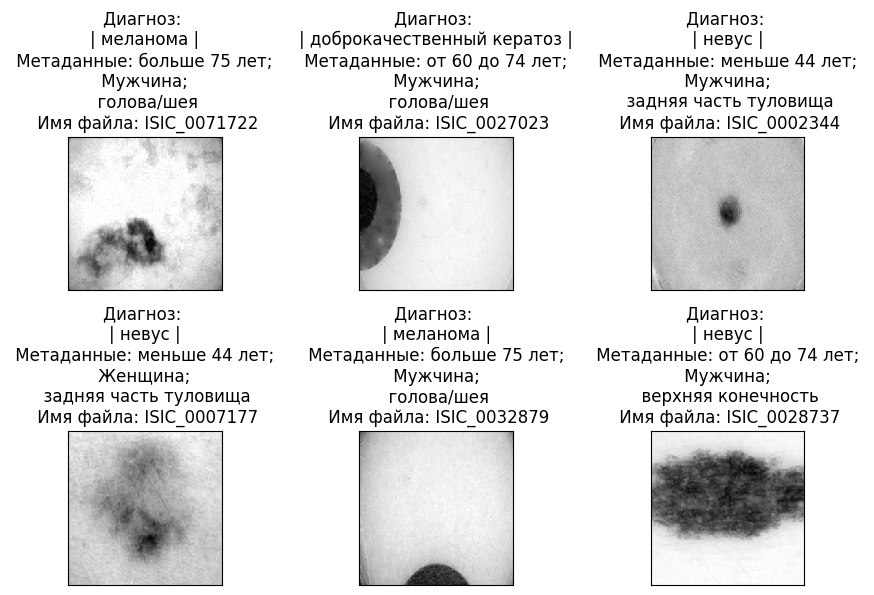

In [14]:
age = ['меньше 44 лет', 'от 45 до 59 лет', 'от 60 до 74 лет', 'больше 75 лет']
sex = ['Мужчина', 'Женщина']
anatomloc = ['торс', 'голова/шея', 'боковая часть туловища', 'нижняя конечность', 'оральная/генитальная зона', 'ладони/подошвы', 'задняя часть туловища', 'верхняя конечность']
lab = ['сосудистое поражение', 'невус', 'солнечное лентиго', 'дерматофиброма', 'себорейный кератоз', 'доброкачественный кератоз', 'актинический кератоз', 'базально-клеточная карцинома', 'плоскоклеточный рак', 'меланома']


examples = enumerate(trainloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

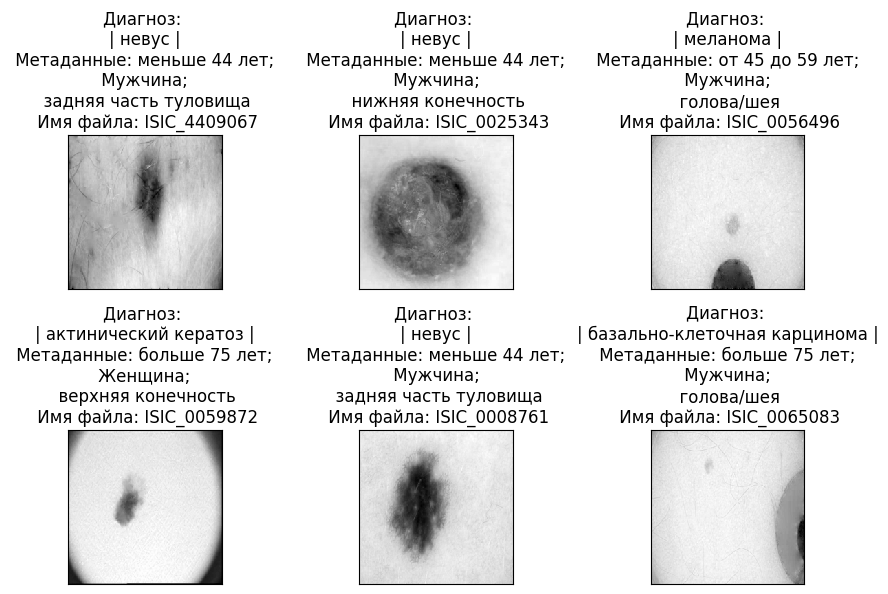

In [15]:
examples = enumerate(valloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

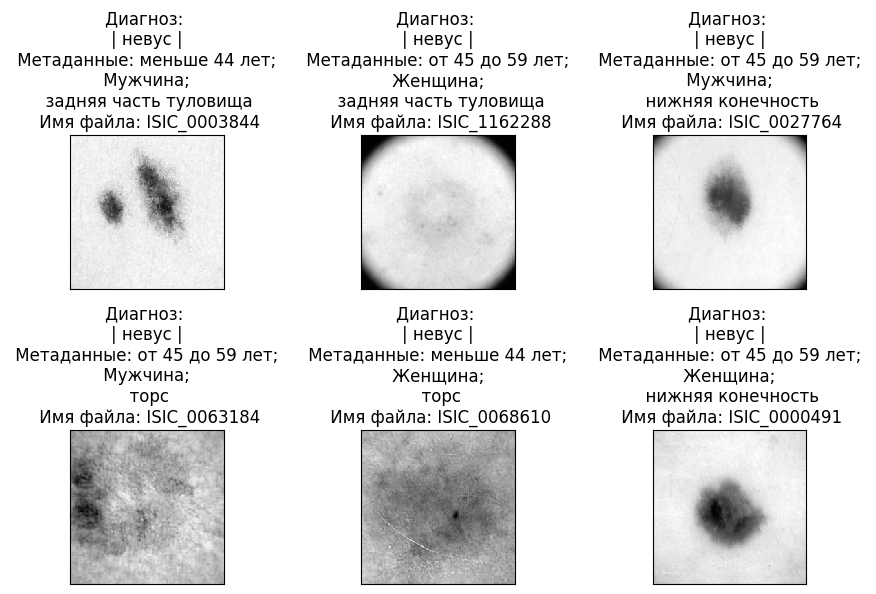

In [16]:
examples = enumerate(testloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

In [17]:
def train_and_evaluate(model, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, name_model):

    start_time_glob = time.time()
    model = model.to(device)
    model.train()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        
        model.train()
        start_time_tarin = time.time()
        
        print('_' * 120)
        print('Эпоха {}/{}\n'.format(epoch+1, num_epochs))
        
        running_loss = 0.0
        running_corrects = 0
        train_accuracy = 0
        total = 0
        correct_train = 0
        
        for i, data in enumerate(trainloader):
            inputs, feats, labels, name = data
            inputs, feats, labels = inputs.to(device), feats.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs, feats)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            loss.backward() 
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            correct_train += preds.eq(labels.data.view_as(preds)).sum()

            total += labels.size(0)
            train_accuracy = 100 * running_corrects / total
            train_accuracy = train_accuracy.cpu()

            if i % 100 == 0:
                print('Тренировочная эпоха: {} [{}/{} ({:.0f}%)]\t\t | Ошибка: {:.4f}\t | Точность распознавания: {:.2f}%'.format(epoch+1, batch_size * i, len_trainset, 100 * i / len(trainloader), loss.item(), train_accuracy))
                
                train_counter.append((i*batch_size) + ((epoch)*len_trainset))
                train_losses.append(loss.item())
                train_acc.append(train_accuracy)
                
        epoch_loss = running_loss / len_trainset
        epoch_acc = running_corrects.double() / len_trainset
        
        time_tarin = time.time()-start_time_tarin
        
        print('\n   Тренировочная ошибка: {:.4f} Точность: {}/{} ({:.2f}%)'.format(epoch_loss, correct_train, len_trainset, 100 * epoch_acc))
        print ('        Время обучения: {}\n'.format(time.strftime("%H:%M:%S", time.gmtime(time_tarin))))
      
        model = model.to(device)
        model.eval()
        start_time_test = time.time()
        
        running_loss_val = 0.0 
        running_corrects_val = 0
        correct = 0
        
        with torch.no_grad():
            
            for data in valloader:
                
                inputs, feats, labels, name = data
                inputs, feats, labels = inputs.to(device), feats.to(device), labels.to(device)
            
                outputs = model(inputs, feats)
            
                loss = criterion(outputs,labels)
                _, preds = torch.max(outputs, 1)

                correct += preds.eq(labels.data.view_as(preds)).sum()
            
                running_loss_val += loss.item() * inputs.size(0)
                running_corrects_val += torch.sum(preds == labels.data)
        
            epoch_loss_val = running_loss_val / len_valset
            epoch_acc_val = running_corrects_val.double() / len_valset
            epoch_acc_val_2 = 100 * epoch_acc_val.cpu()

            test_losses.append(epoch_loss_val)
            test_acc.append(epoch_acc_val_2)

            time_test = time.time()-start_time_test
        
            if epoch_acc_val > best_acc:
                best_acc = epoch_acc_val
                best_model_wts = copy.deepcopy(model.state_dict())
            
                torch.save(model.state_dict(), f"BestModel_{model_name}_{name_model}.pth")

            scheduler.step(best_acc)

            print('   Валидационная ошибка: {:.4f} Точность: {}/{} ({:.2f}%)'.format(epoch_loss_val, correct, len_valset, 100 * epoch_acc_val))
            print ('        Время тестирования: {}\n'.format(time.strftime("%H:%M:%S", time.gmtime(time_test))))
        
            print('Лучшая валидационная точность: {:.4f}'.format(best_acc))

            #torch.save(model.state_dict(), f"{name_model}_epoch-{epoch+1}.pth")
            
            #model.load_state_dict(best_model_wts)

    time_glob = time.time()-start_time_glob
    print('_' * 120)
    print ('\nОбщее время обучения: {}'.format(time.strftime("%H:%M:%S", time.gmtime(time_glob))))
    
    return model

In [28]:
num_metadata_features = 3
num_classes = 10

fp32_model = Multimodal_NN(num_metadata_features, num_classes)
device = get_default_device()

# Замораживаем часть AlexNet для тонкой настройки
#for param in fp32_model.visual_features.parameters():
    #param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(fp32_model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 5)

num_epochs = 20

train_losses = []
train_counter = []
train_acc = []

test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []

fp32_model = train_and_evaluate(fp32_model, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'fp32_model')

________________________________________________________________________________________________________________________
Эпоха 1/20

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 2.4665	 | Точность распознавания: 9.38%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.6231	 | Точность распознавания: 75.00%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.5344	 | Точность распознавания: 76.00%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.5811	 | Точность распознавания: 76.76%

   Тренировочная ошибка: 0.6721 Точность: 19348/25035 (77.28%)
        Время обучения: 00:00:20

   Валидационная ошибка: 0.5471 Точность: 6710/8345 (80.41%)
        Время тестирования: 00:00:04

Лучшая валидационная точность: 0.8041
________________________________________________________________________________________________________________________
Эпоха 2/20

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.6019	 | Точность распознавания: 71.88%
Тренировочная эпоха: 2 [6400/25

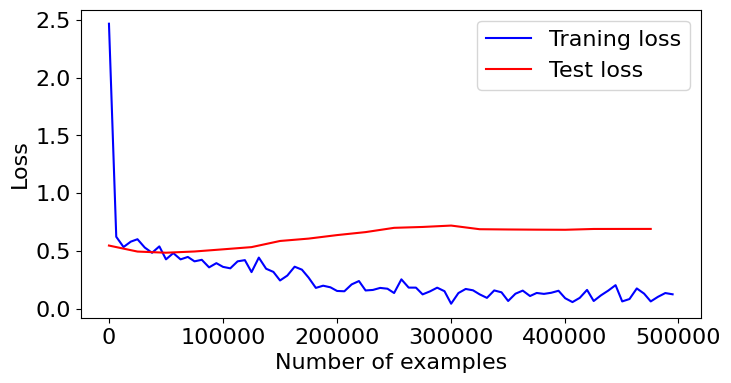

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(8, 4))
plt.rcParams['font.size'] = '16'
plt.plot(train_counter, train_losses, color='blue')
plt.plot(test_counter, test_losses, color='red')
plt.legend(['Traning loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
fig = plt.figure()
plt.show()

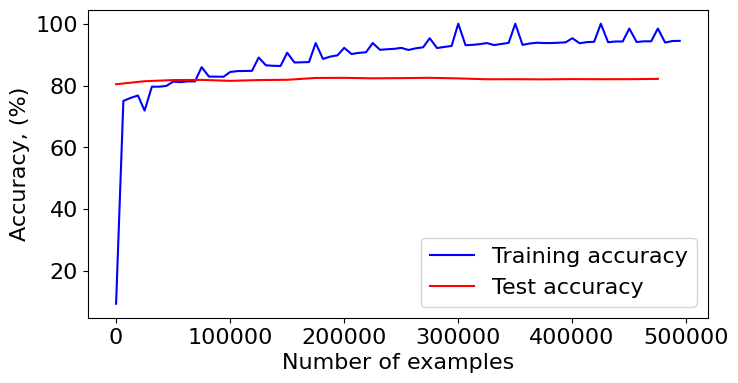

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(8, 4))
plt.rcParams['font.size'] = '16'
plt.plot(train_counter, train_acc, color='blue')
plt.plot(test_counter, test_acc, color='red')
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy, (%)')
fig = plt.figure()
plt.show()

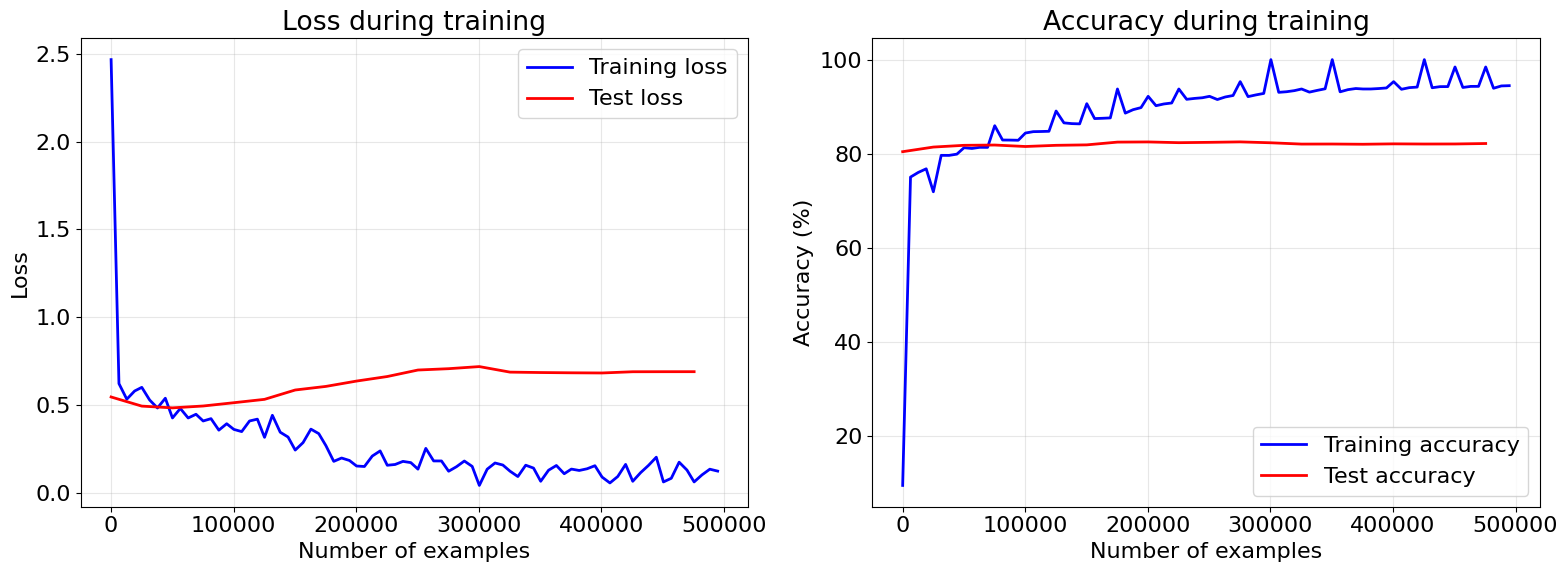

In [31]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

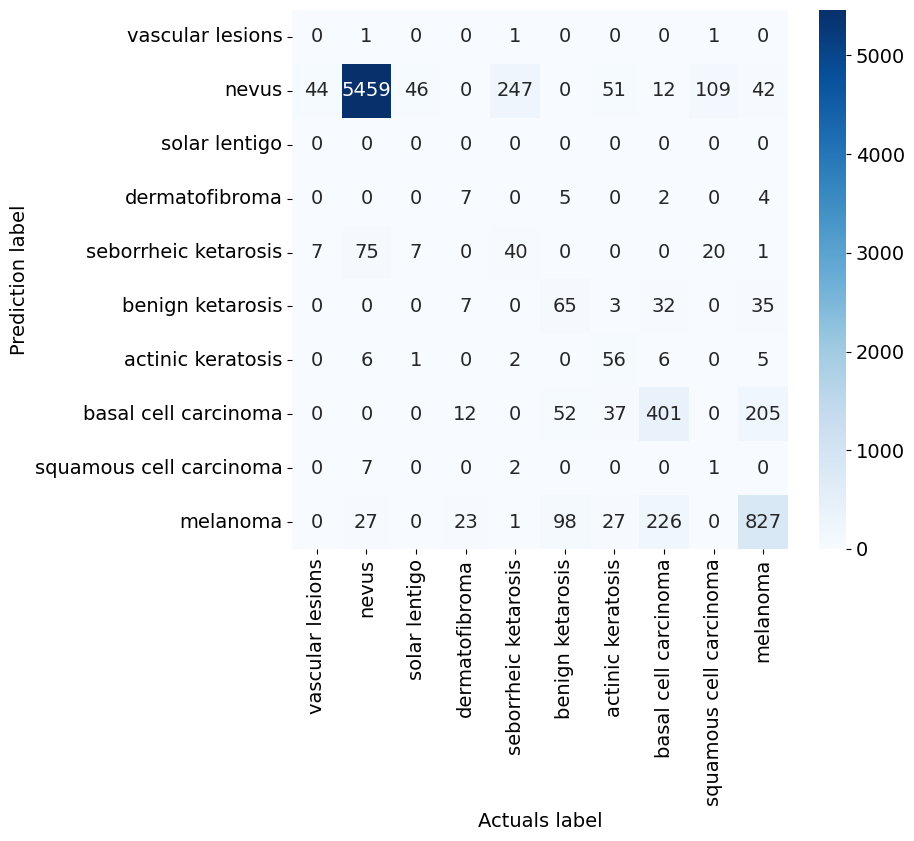

Sensitivity: 0.8216
Specificity: 0.9802
Precision: 0.8216
NPV: 0.9802
PPV: 0.8216
FNR: 0.1784
FPR: 0.0198
F1: 0.8216
Recall micro: 0.8216
Recall macro: 0.3213
Precision micro: 0.8216
Precision macro: 0.4099
F1 score micro: 0.8216
F1 score macro: 0.3436
Jaccard score micro: 0.6972
Jaccard score macro: 0.2573
Accuracy score: 0.8216
Matthews corrcoef: 0.6408
Specificity macro: 0.9677
Specificity micro: 0.9802
Specificity weighted: 0.8556
Specificity none - class vascular lesions (0): 0.9996
Specificity none - class nevus (1): 0.8011
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 0.9987
Specificity none - class seborrheic ketarosis (4): 0.9863
Specificity none - class benign ketarosis (5): 0.9905
Specificity none - class actinic keratosis (6): 0.9976
Specificity none - class basal cell carcinoma (7): 0.9601
Specificity none - class squamous cell carcinoma (8): 0.9989
Specificity none - class melanoma (9): 0.9444


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
actuals = []
predictions = []

test_NN(fp32_model, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

fp32_final_acc = test_metric()

In [33]:
class QuantizedCNN(nn.Module):
    def __init__(self, original_alexnet):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.features = original_alexnet
        #self.avgpool = original_alexnet.avgpool
        self.classifier = nn.Identity()
        
    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        #x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dequant(x)
        return x

def quantize_CNN_separately(model, calibration_loader):
    
    visual_classifier_state = model.visual_classifier.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    quantized_alexnet = QuantizedCNN(model.visual_features)
    quantized_alexnet = quantized_alexnet.to(device)
    quantized_alexnet.qconfig = get_default_qconfig('fbgemm')
    
    # Подготовка и калибровка
    model_prepared = prepare(quantized_alexnet, inplace=False)
    
    model_prepared.eval()
    with torch.no_grad():
        for i, data in enumerate(calibration_loader):
            images, metadata, label, name = data
            images, metadata = images.to(device), metadata.to(device)
            model_prepared(images)
            if i >= 50:
                break
    
    # Конвертация
    model_quantized_alexnet = convert(model_prepared, inplace=False)
    
    # Заменяем в основной модели
    model.visual_features = model_quantized_alexnet

    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.metadata_net.load_state_dict(metadata_net_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)
    
    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

from torch.quantization import QuantStub, DeQuantStub, prepare, convert, get_default_qconfig

ptq_model_CNN = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_CNN.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_CNN = quantize_CNN_separately(ptq_model_CNN, trainloader)
print(f"PTQ мультимодальная модель ptq_model_model_quantized_CNN на int_8 успешно сконвертирована!")

#ptq_model_model_quantized_CNN

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель ptq_model_model_quantized_CNN на int_8 успешно сконвертирована!


In [34]:
def check_quantization_status(model):
    
    for name, module in model.named_modules():
        # Проверяем тип модуля
        module_type = type(module).__name__
        
        # Для обычных слоев
        if hasattr(module, 'weight') and not callable(module.weight):
            weight = module.weight
            print(f"{name}: {module_type} | dtype: {weight.dtype} | shape: {weight.shape}")
        
        # Для квантованных слоев
        elif hasattr(module, '_packed_params'):
            print(f"{name}: {module_type} | КВАНТОВАННЫЙ СЛОЙ")
        
        # Для QuantStub/DeQuantStub
        elif isinstance(module, (QuantStub, DeQuantStub)):
            print(f"{name}: {module_type}")

def get_model_size(model, model_name=""):
    torch.save(model.state_dict(), "temp_model.pth")

    size_bytes = os.path.getsize("temp_model.pth")
    size_mb = size_bytes / (1024 * 1024)

    os.remove("temp_model.pth")

    print("_" * 50)
    print(f"Размер {model_name}: {size_mb:.2f} МБ")
    return size_mb

def check_by_size_comparison_complete(original_model, quantized_model):
    print("ПОЛНОЕ СРАВНЕНИЕ КОМПОНЕНТОВ:")
    print("_" * 60)
    
    def get_component_size(component, name):
        torch.save(component.state_dict(), f"temp_{name}.pth")
        size_mb = os.path.getsize(f"temp_{name}.pth") / (1024 * 1024)
        os.remove(f"temp_{name}.pth")
        return size_mb
    
    total_orig_size = 0
    total_quant_size = 0
    
    # Компоненты для сравнения
    components_mapping = {
        'visual_features': 'CNN',
        'metadata_net': 'MLP', 
        'visual_classifier': 'CNN_classifier',
        'combined_classifier': 'Cat_classifier',
        'quantized_classifiers': 'Quant_classifiers'
    }
    
    print(f"{'Компонент':<25} {'Оригинал':<10} {'Квантован':<10} {'Сокращение':<12} Статус")
    print("_" * 60)
    
    # Основные компоненты
    main_components = ['visual_features', 'metadata_net', 'visual_classifier', 'combined_classifier']
    
    for comp in main_components:
        if hasattr(original_model, comp):
            orig_size = get_component_size(getattr(original_model, comp), f"orig_{comp}")
            total_orig_size += orig_size
            
            if hasattr(quantized_model, comp):
                quant_size = get_component_size(getattr(quantized_model, comp), f"quant_{comp}")
                total_quant_size += quant_size
                reduction = ((orig_size - quant_size) / orig_size) * 100
                status = "✅" if reduction > 10 else "⚪"
            else:
                quant_size = 0
                reduction = 100.0
                status = "🔄 ЗАМЕНЕН"
            
            print(f"{components_mapping.get(comp, comp):<25} {orig_size:>7.4f} МБ {quant_size:>7.4f} МБ {reduction:>9.2f}%   {status}")
    
    # Quantized classifiers (специальная обработка)
    if hasattr(quantized_model, 'quantized_classifiers'):
        # Размер квантованных классификаторов
        quant_size = get_component_size(quantized_model.quantized_classifiers, "quant_qc")
        total_quant_size += quant_size
        
        # Размер оригинальных классификаторов которые были заменены
        vc_size = get_component_size(original_model.visual_classifier, "orig_vc") if hasattr(original_model, 'visual_classifier') else 0
        cc_size = get_component_size(original_model.combined_classifier, "orig_cc") if hasattr(original_model, 'combined_classifier') else 0
        orig_combined_size = vc_size + cc_size
        
        reduction = ((orig_combined_size - quant_size) / orig_combined_size) * 100 if orig_combined_size > 0 else 0
        
        print(f"{'Quant_classifiers':<25} {orig_combined_size:>7.4f} МБ {quant_size:>7.4f} МБ {reduction:>9.2f}%   ✅")
    
    # Итоги
    total_reduction = ((total_orig_size - total_quant_size) / total_orig_size) * 100
    
    print("_" * 60)
    print(f"{'ОБЩИЙ РАЗМЕР':<25} {total_orig_size:>7.4f} МБ {total_quant_size:>7.4f} МБ {total_reduction:>9.2f}%   ")
    print("_" * 60)
    
    return total_orig_size, total_quant_size, total_reduction

check_quantization_status(ptq_model_model_quantized_CNN)
check_by_size_comparison_complete(fp32_model, ptq_model_model_quantized_CNN)

visual_features.features.features.0: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.9.squeeze: Conv2d | КВ

(172.0572452545166, 170.0745506286621, 1.152345908433894)

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

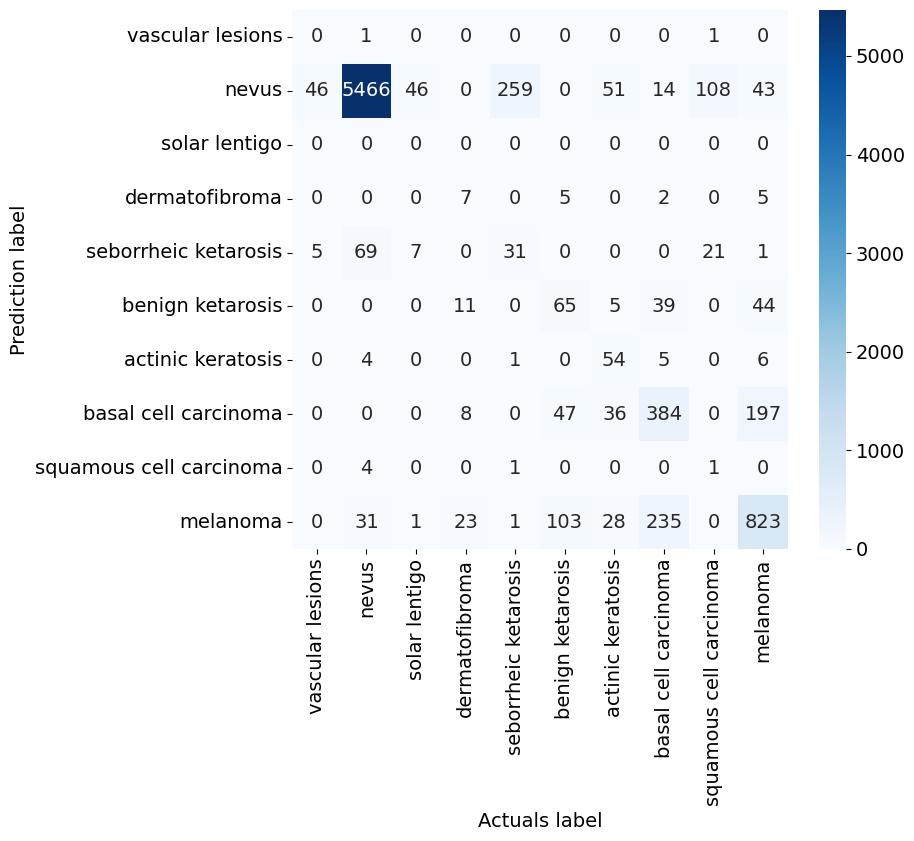

Sensitivity: 0.8186
Specificity: 0.9798
Precision: 0.8186
NPV: 0.9798
PPV: 0.8186
FNR: 0.1814
FPR: 0.0202
F1: 0.8186
Recall micro: 0.8186
Recall macro: 0.3144
Precision micro: 0.8186
Precision macro: 0.4073
F1 score micro: 0.8186
F1 score macro: 0.3353
Jaccard score micro: 0.6929
Jaccard score macro: 0.2509
Accuracy score: 0.8186
Matthews corrcoef: 0.6338
Specificity macro: 0.9670
Specificity micro: 0.9798
Specificity weighted: 0.8515
Specificity none - class vascular lesions (0): 0.9998
Specificity none - class nevus (1): 0.7953
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 0.9986
Specificity none - class seborrheic ketarosis (4): 0.9872
Specificity none - class benign ketarosis (5): 0.9878
Specificity none - class actinic keratosis (6): 0.9980
Specificity none - class basal cell carcinoma (7): 0.9624
Specificity none - class squamous cell carcinoma (8): 0.9994
Specificity none - class melanoma (9): 0.9416


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_CNN, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_CNN = test_metric()

In [36]:
class QuantizedMLP(nn.Module):
    def __init__(self, original_metadata_net):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.metadata_net = original_metadata_net
        
    def forward(self, x):
        x = self.quant(x)
        x = self.metadata_net(x)
        x = self.dequant(x)
        return x

def quantize_MLP_separately(model, calibration_loader):
    visual_features_state = model.visual_features.state_dict().copy()
    visual_classifier_state = model.visual_classifier.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    quantized_metadata_net = QuantizedMLP(model.metadata_net)
    quantized_metadata_net = quantized_metadata_net.to(device)
    quantized_metadata_net.qconfig = get_default_qconfig('fbgemm')

    model_prepared = prepare(quantized_metadata_net, inplace=False)

    model_prepared.eval()
    with torch.no_grad():
        for i, data in enumerate(calibration_loader):
            images, metadata, label, name = data
            images, metadata = images.to(device), metadata.to(device)
            model_prepared(metadata)
            if i >= 50:
                break

    model_quantized_metadata_net = convert(model_prepared, inplace=False)

    model.metadata_net = model_quantized_metadata_net

    model.visual_features.load_state_dict(visual_features_state)
    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)

    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_MLP = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_MLP.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_MLP = quantize_MLP_separately(ptq_model_MLP, trainloader)
print(f"PTQ мультимодальная модель ptq_model_model_quantized_MLP на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель ptq_model_model_quantized_MLP на int_8 успешно сконвертирована!


In [37]:
check_quantization_status(ptq_model_model_quantized_MLP)
check_by_size_comparison_complete(fp32_model, ptq_model_model_quantized_MLP)

visual_features.features.0: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 3, 3, 3])
visual_features.features.3.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 64, 1, 1])
visual_features.features.3.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.3.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.4.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 128, 1, 1])
visual_features.features.4.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.4.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.6.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([32, 128, 1, 1])
visual_features.features.6.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([128, 32, 1, 1])
visual_features.features.6.expand3x3: Conv2d | dtype: torch.float32 | shape: t

(172.0572452545166, 172.05547523498535, 0.0010287387367103832)

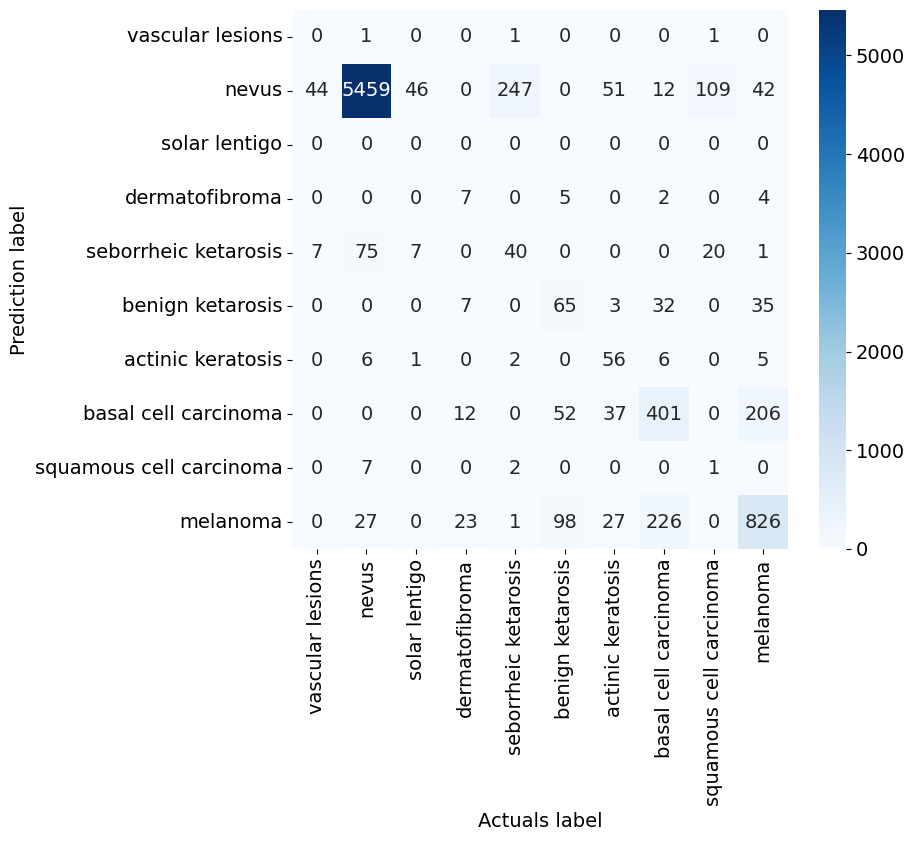

Sensitivity: 0.8214
Specificity: 0.9802
Precision: 0.8214
NPV: 0.9802
PPV: 0.8214
FNR: 0.1786
FPR: 0.0198
F1: 0.8214
Recall micro: 0.8214
Recall macro: 0.3212
Precision micro: 0.8214
Precision macro: 0.4097
F1 score micro: 0.8214
F1 score macro: 0.3435
Jaccard score micro: 0.6970
Jaccard score macro: 0.2571
Accuracy score: 0.8214
Matthews corrcoef: 0.6406
Specificity macro: 0.9677
Specificity micro: 0.9802
Specificity weighted: 0.8556
Specificity none - class vascular lesions (0): 0.9996
Specificity none - class nevus (1): 0.8011
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 0.9987
Specificity none - class seborrheic ketarosis (4): 0.9863
Specificity none - class benign ketarosis (5): 0.9905
Specificity none - class actinic keratosis (6): 0.9976
Specificity none - class basal cell carcinoma (7): 0.9600
Specificity none - class squamous cell carcinoma (8): 0.9989
Specificity none - class melanoma (9): 0.9444


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_MLP, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_MLP = test_metric()

In [39]:
class QuantizedClassifiers(nn.Module):
    def __init__(self, original_visual_classifier, original_combined_classifier):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.visual_classifier = original_visual_classifier
        self.combined_classifier = original_combined_classifier
        
    def forward(self, visual_features, metadata_features):
        visual_features = self.quant(visual_features)
        visual_out = self.visual_classifier(visual_features)
        visual_out = self.dequant(visual_out)
        
        combined_features = torch.cat((visual_out, metadata_features), dim=1)
        
        combined_features = self.quant(combined_features)
        output = self.combined_classifier(combined_features)
        output = self.dequant(output)
        
        return output

def quantize_classifiers_together(model, calibration_loader):
    visual_features_state = model.visual_features.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    
    quantized_classifiers = QuantizedClassifiers(
        model.visual_classifier, 
        model.combined_classifier
    )
    quantized_classifiers = quantized_classifiers.to(device)
    quantized_classifiers.qconfig = get_default_qconfig('fbgemm')

    model_prepared = prepare(quantized_classifiers, inplace=False)

    model_prepared.eval()
    with torch.no_grad():
        for i, data in enumerate(calibration_loader):
            images, metadata, label, name = data
            images, metadata = images.to(device), metadata.to(device)

            with torch.no_grad():
                visual_features = model.visual_features(images)
                visual_features = visual_features.reshape(visual_features.size(0), -1)

                metadata_features = model.metadata_net(metadata)

            model_prepared(visual_features, metadata_features)
            if i >= 50:
                break

    model_quantized_classifiers = convert(model_prepared, inplace=False)
    

    class Multimodal_With_QuantizedClassifiers(nn.Module):
        def __init__(self, visual_features, metadata_net, quantized_classifiers):
            super().__init__()
            self.visual_features = visual_features
            self.metadata_net = metadata_net
            self.quantized_classifiers = quantized_classifiers
            
        def forward(self, image, metadata):
            visual_features = self.visual_features(image)
            visual_features = visual_features.reshape(visual_features.size(0), -1)
            
            metadata_features = self.metadata_net(metadata)

            output = self.quantized_classifiers(visual_features, metadata_features)
            return output

    final_model = Multimodal_With_QuantizedClassifiers(
        model.visual_features,
        model.metadata_net, 
        model_quantized_classifiers
    )

    final_model.visual_features.load_state_dict(visual_features_state)
    final_model.metadata_net.load_state_dict(metadata_net_state)

    return final_model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_linear = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_linear.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_linear = quantize_classifiers_together(ptq_model_linear, trainloader)
print(f"PTQ мультимодальная модель ptq_model_model_quantized_linear на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель ptq_model_model_quantized_linear на int_8 успешно сконвертирована!


In [40]:
check_quantization_status(ptq_model_model_quantized_linear)
check_by_size_comparison_complete(fp32_model, ptq_model_model_quantized_linear)

visual_features.features.0: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 3, 3, 3])
visual_features.features.3.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 64, 1, 1])
visual_features.features.3.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.3.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.4.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 128, 1, 1])
visual_features.features.4.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.4.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.6.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([32, 128, 1, 1])
visual_features.features.6.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([128, 32, 1, 1])
visual_features.features.6.expand3x3: Conv2d | dtype: torch.float32 | shape: t

(172.0572452545166, 45.12312698364258, 73.77435229949548)

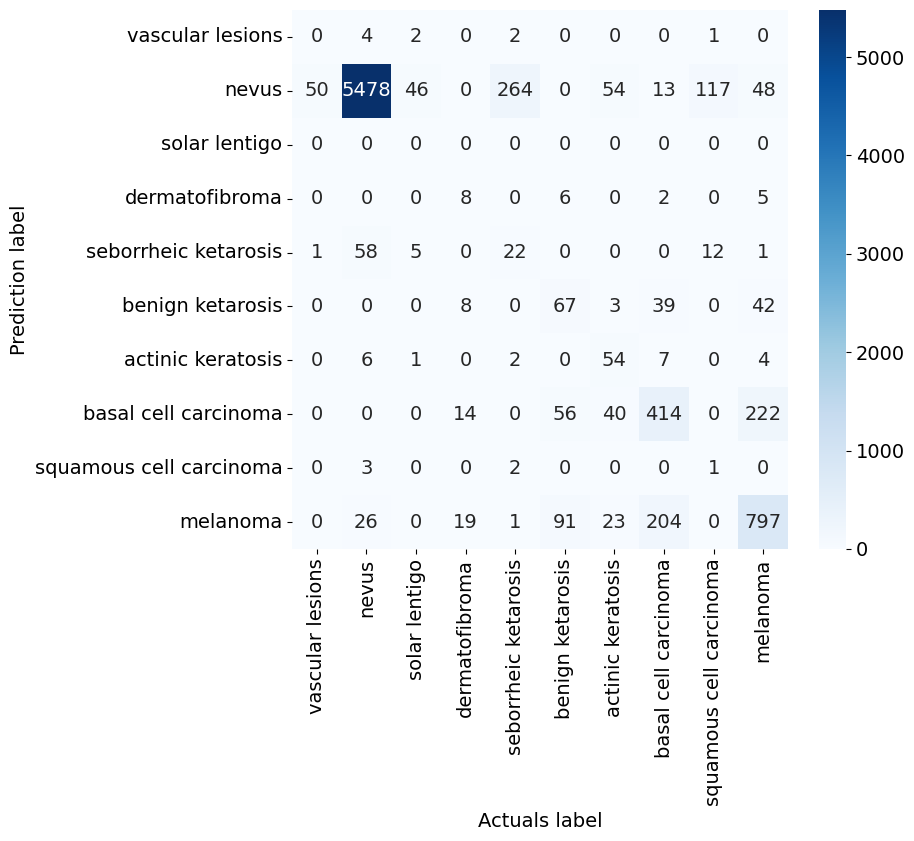

Sensitivity: 0.8198
Specificity: 0.9800
Precision: 0.8198
NPV: 0.9800
PPV: 0.8198
FNR: 0.1802
FPR: 0.0200
F1: 0.8198
Recall micro: 0.8198
Recall macro: 0.3165
Precision micro: 0.8198
Precision macro: 0.4065
F1 score micro: 0.8198
F1 score macro: 0.3365
Jaccard score micro: 0.6946
Jaccard score macro: 0.2524
Accuracy score: 0.8198
Matthews corrcoef: 0.6353
Specificity macro: 0.9666
Specificity micro: 0.9800
Specificity weighted: 0.8462
Specificity none - class vascular lesions (0): 0.9989
Specificity none - class nevus (1): 0.7863
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 0.9984
Specificity none - class seborrheic ketarosis (4): 0.9904
Specificity none - class benign ketarosis (5): 0.9887
Specificity none - class actinic keratosis (6): 0.9976
Specificity none - class basal cell carcinoma (7): 0.9567
Specificity none - class squamous cell carcinoma (8): 0.9994
Specificity none - class melanoma (9): 0.9496


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_linear, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_linear = test_metric()

In [42]:
class QuantizedMultimodal(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()

        self.visual_features = original_model.visual_features
        self.visual_classifier = original_model.visual_classifier
        self.metadata_net = original_model.metadata_net
        self.combined_classifier = original_model.combined_classifier
        
    def forward(self, image, metadata):
        image = self.quant(image)
        metadata = self.quant(metadata)

        visual_feat = self.visual_features(image)
        visual_feat = visual_feat.view(visual_feat.size(0), -1)
        visual_out = self.visual_classifier(visual_feat)
        
        metadata_out = self.metadata_net(metadata)

        visual_out = self.dequant(visual_out)
        metadata_out = self.dequant(metadata_out)
        
        combined = torch.cat((visual_out, metadata_out), dim=1)

        combined = self.quant(combined)
        output = self.combined_classifier(combined)
        output = self.dequant(output)
        
        return output

def quantize_completely_simple(model, calibration_loader):
    
    quant_model = QuantizedMultimodal(model)
    quant_model = quant_model.to(device)

    quant_model.qconfig = get_default_qconfig('fbgemm')

    model_prepared = prepare(quant_model, inplace=False)
   
    print("Калибровка...")
    model_prepared.eval()
    with torch.no_grad():
        for i, (images, metadata, _, _) in enumerate(calibration_loader):
            images, metadata = images.to(device), metadata.to(device)
            model_prepared(images, metadata)
            if i >= 30:
                break
                
    model_quantized = convert(model_prepared, inplace=False)
    
    return model_quantized

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_full = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_full.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_full = quantize_completely_simple(ptq_model_full, trainloader)
print(f"PTQ мультимодальная модель на int_8 успешно сконвертирована!")

Калибровка...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель на int_8 успешно сконвертирована!


In [43]:
check_quantization_status(ptq_model_model_quantized_full)
check_by_size_comparison_complete(fp32_model, ptq_model_model_quantized_full)

visual_features.features.0: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.expand3x3: Conv2d 

(172.0572452545166, 43.13621520996094, 74.92914922231176)

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

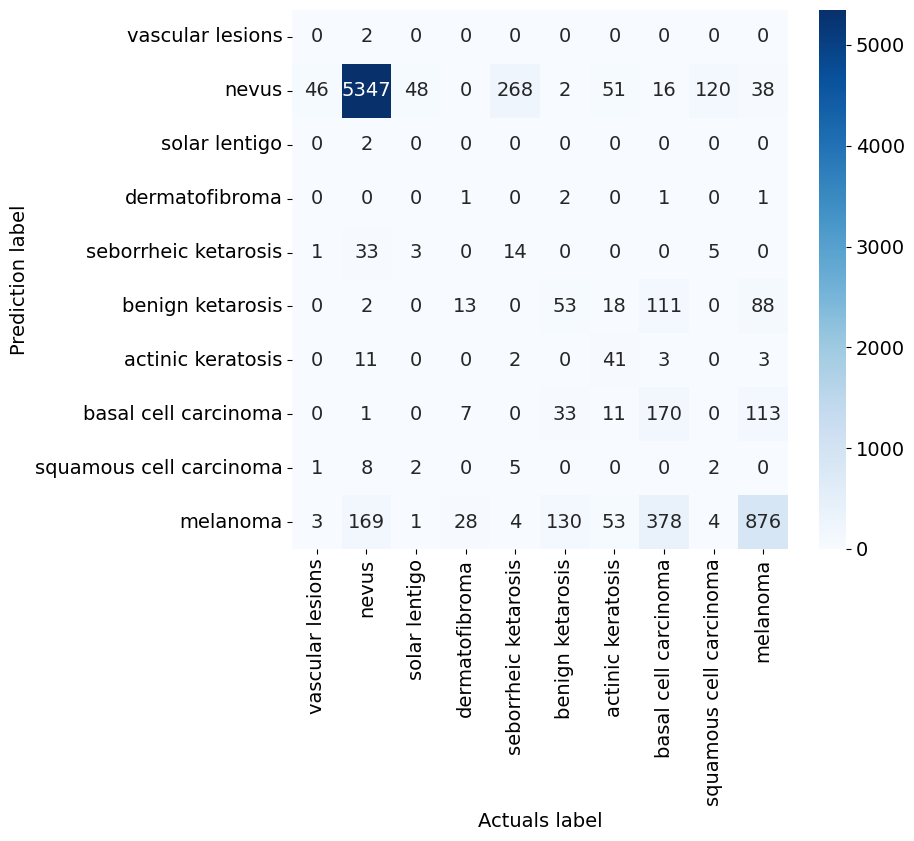

Sensitivity: 0.7794
Specificity: 0.9755
Precision: 0.7794
NPV: 0.9755
PPV: 0.7794
FNR: 0.2206
FPR: 0.0245
F1: 0.7794
Recall micro: 0.7794
Recall macro: 0.2552
Precision micro: 0.7794
Precision macro: 0.3371
F1 score micro: 0.7794
F1 score macro: 0.2602
Jaccard score micro: 0.6385
Jaccard score macro: 0.1937
Accuracy score: 0.7794
Matthews corrcoef: 0.5598
Specificity macro: 0.9620
Specificity micro: 0.9755
Specificity weighted: 0.8409
Specificity none - class vascular lesions (0): 0.9998
Specificity none - class nevus (1): 0.7874
Specificity none - class solar lentigo (2): 0.9998
Specificity none - class dermatofibroma (3): 0.9995
Specificity none - class seborrheic ketarosis (4): 0.9948
Specificity none - class benign ketarosis (5): 0.9714
Specificity none - class actinic keratosis (6): 0.9977
Specificity none - class basal cell carcinoma (7): 0.9785
Specificity none - class squamous cell carcinoma (8): 0.9981
Specificity none - class melanoma (9): 0.8934


In [44]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_full, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_full = test_metric()

In [45]:
class QuantizedCNN_QAT(nn.Module):
    def __init__(self, original_alexnet):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.features = original_alexnet
        self.classifier = nn.Identity()
        
    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dequant(x)
        return x

def QAT_quantize_CNN_separately(model):
    
    visual_classifier_state = model.visual_classifier.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    quantized_alexnet = QuantizedCNN_QAT(model.visual_features)

    device = torch.device("cpu")
    quantized_alexnet = quantized_alexnet.to(device)
    quantized_alexnet.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
    
    # Подготовка
    model_prepared = prepare_qat(quantized_alexnet, inplace=False)
    
    # Заменяем в основной модели
    model.visual_features = model_prepared

    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.metadata_net.load_state_dict(metadata_net_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)
    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_CNN = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_CNN.load_state_dict(fp32_model.state_dict())

qat_model_CNN = QAT_quantize_CNN_separately(qat_model_CNN)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_CNN.parameters(), lr=0.001, momentum=0.9)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cuda")
qat_model_CNN  = train_and_evaluate(qat_model_CNN, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_CNN')

device = torch.device("cpu")
qat_model_CNN .eval()
qat_model_CNN  = qat_model_CNN.to(device)
qat_model_CNN.visual_features = convert(qat_model_CNN.visual_features, inplace=False)

print(f"QAT мультимодальная модель qat_model_CNN на int_8 успешно сконвертирована!")

Начало QAT с предобученными весами...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 0.0899	 | Точность распознавания: 96.88%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.2620	 | Точность распознавания: 91.41%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.2364	 | Точность распознавания: 91.16%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.2385	 | Точность распознавания: 90.66%

   Тренировочная ошибка: 0.2469 Точность: 22683/25035 (90.61%)
        Время обучения: 00:00:23

   Валидационная ошибка: 0.7170 Точность: 6800/8345 (81.49%)
        Время тестирования: 00:00:05

Лучшая валидационная точность: 0.8149
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.1817	 | Точность распознавания: 92.19%
Тренировочная эпоха: 2 [6400/250

In [46]:
check_quantization_status(qat_model_CNN)
check_by_size_comparison_complete(fp32_model, qat_model_CNN)

visual_features.features.features.0: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.3.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.4.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.6.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.7.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.features.9.squeeze: Conv2d | КВ

(172.0572452545166, 170.0745506286621, 1.152345908433894)

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

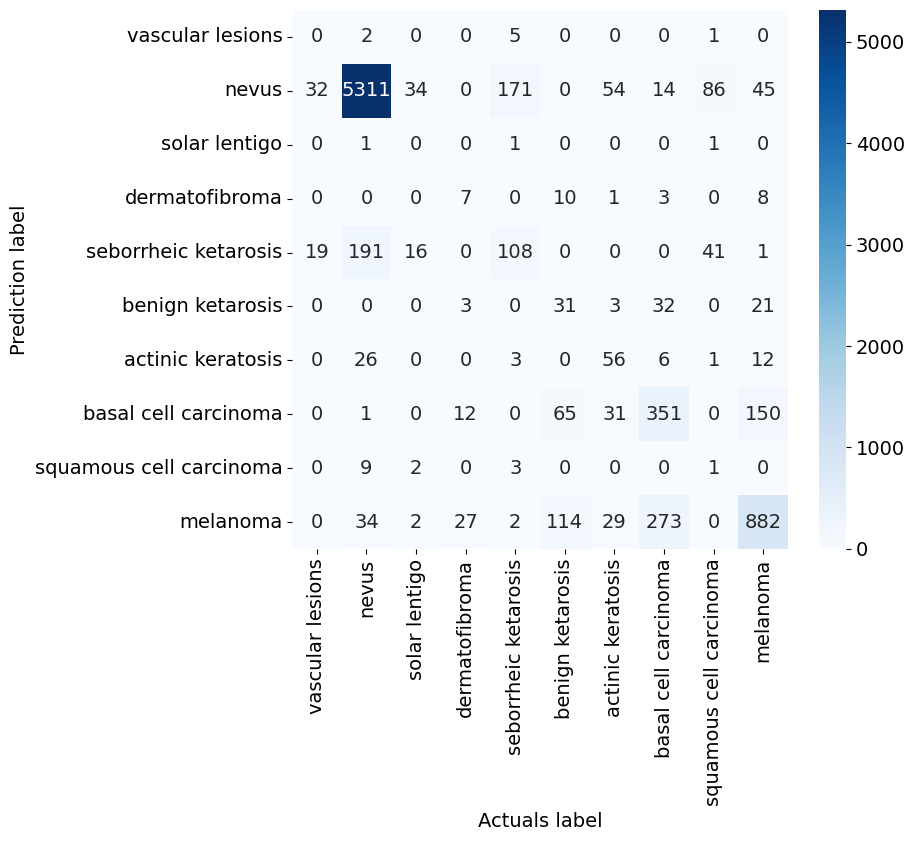

Sensitivity: 0.8085
Specificity: 0.9787
Precision: 0.8085
NPV: 0.9787
PPV: 0.8085
FNR: 0.1915
FPR: 0.0213
F1: 0.8085
Recall micro: 0.8085
Recall macro: 0.3240
Precision micro: 0.8085
Precision macro: 0.3625
F1 score micro: 0.8085
F1 score macro: 0.3312
Jaccard score micro: 0.6786
Jaccard score macro: 0.2470
Accuracy score: 0.8085
Matthews corrcoef: 0.6261
Specificity macro: 0.9690
Specificity micro: 0.9787
Specificity weighted: 0.8816
Specificity none - class vascular lesions (0): 0.9990
Specificity none - class nevus (1): 0.8426
Specificity none - class solar lentigo (2): 0.9996
Specificity none - class dermatofibroma (3): 0.9973
Specificity none - class seborrheic ketarosis (4): 0.9667
Specificity none - class benign ketarosis (5): 0.9927
Specificity none - class actinic keratosis (6): 0.9941
Specificity none - class basal cell carcinoma (7): 0.9662
Specificity none - class squamous cell carcinoma (8): 0.9983
Specificity none - class melanoma (9): 0.9334


In [47]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_CNN, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_CNN = test_metric()

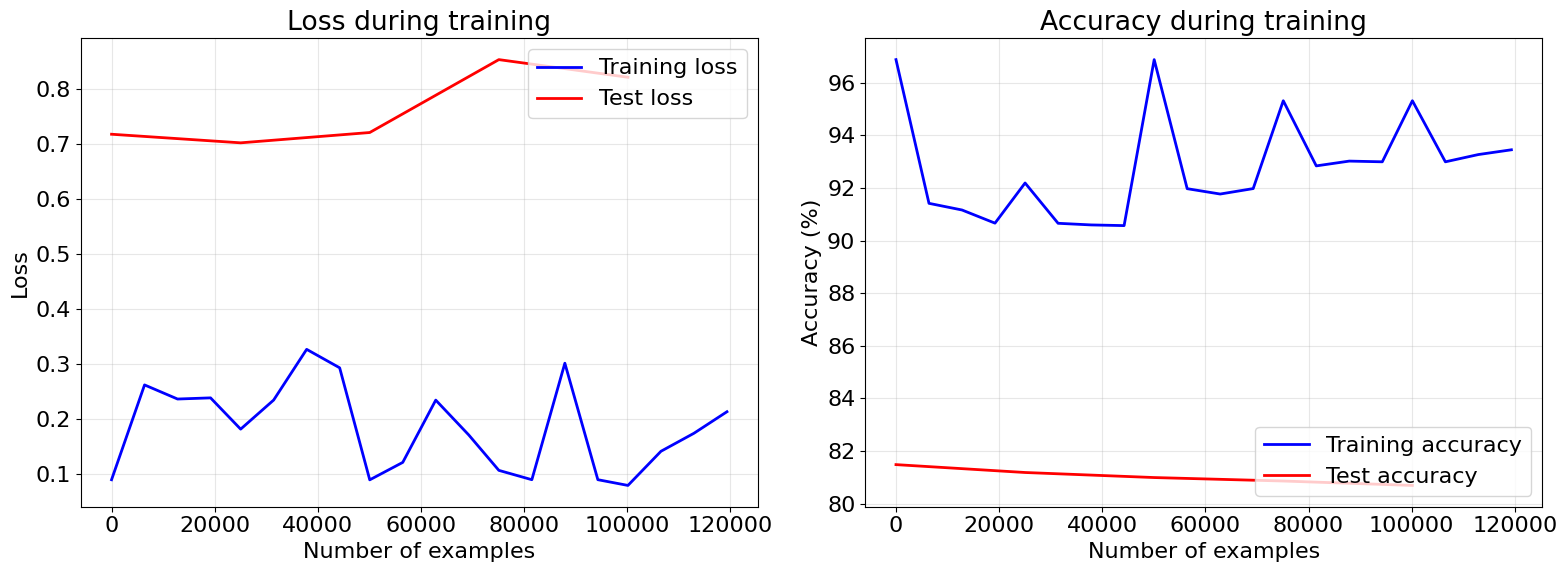

In [48]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

In [49]:
class QuantizedMLP_QAT(nn.Module):
    def __init__(self, original_metadata_net):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.metadata_net = original_metadata_net
        
    def forward(self, x):
        x = self.quant(x)
        x = self.metadata_net(x)
        x = self.dequant(x)
        return x

def QAT_quantize_MLP_separately(model):
    visual_features_state = model.visual_features.state_dict().copy()
    visual_classifier_state = model.visual_classifier.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    quantized_metadata_net = QuantizedMLP_QAT(model.metadata_net)
    quantized_metadata_net = quantized_metadata_net.to(device)
    quantized_metadata_net.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

    model_prepared = prepare_qat(quantized_metadata_net, inplace=False)

    model.metadata_net = model_prepared

    model.visual_features.load_state_dict(visual_features_state)
    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)

    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_MLP = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_MLP.load_state_dict(fp32_model.state_dict())

qat_model_MLP = QAT_quantize_MLP_separately(qat_model_MLP)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_MLP.parameters(), lr=0.001, momentum=0.9)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cuda")
qat_model_MLP  = train_and_evaluate(qat_model_MLP, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_MLP')

device = torch.device("cpu")
qat_model_MLP .eval()
qat_model_MLP  = qat_model_MLP.to(device)
qat_model_MLP.metadata_net = convert(qat_model_MLP.metadata_net, inplace=False)

print(f"QAT мультимодальная модель qat_model_MLP на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Начало QAT с предобученными весами...
________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 0.0577	 | Точность распознавания: 98.44%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.2250	 | Точность распознавания: 91.34%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.2295	 | Точность распознавания: 91.01%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.2422	 | Точность распознавания: 90.81%

   Тренировочная ошибка: 0.2307 Точность: 22755/25035 (90.89%)
        Время обучения: 00:00:21

   Валидационная ошибка: 0.7211 Точность: 6739/8345 (80.75%)
        Время тестирования: 00:00:05

Лучшая валидационная точность: 0.8075
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.1432	 | Точность распознавания: 9

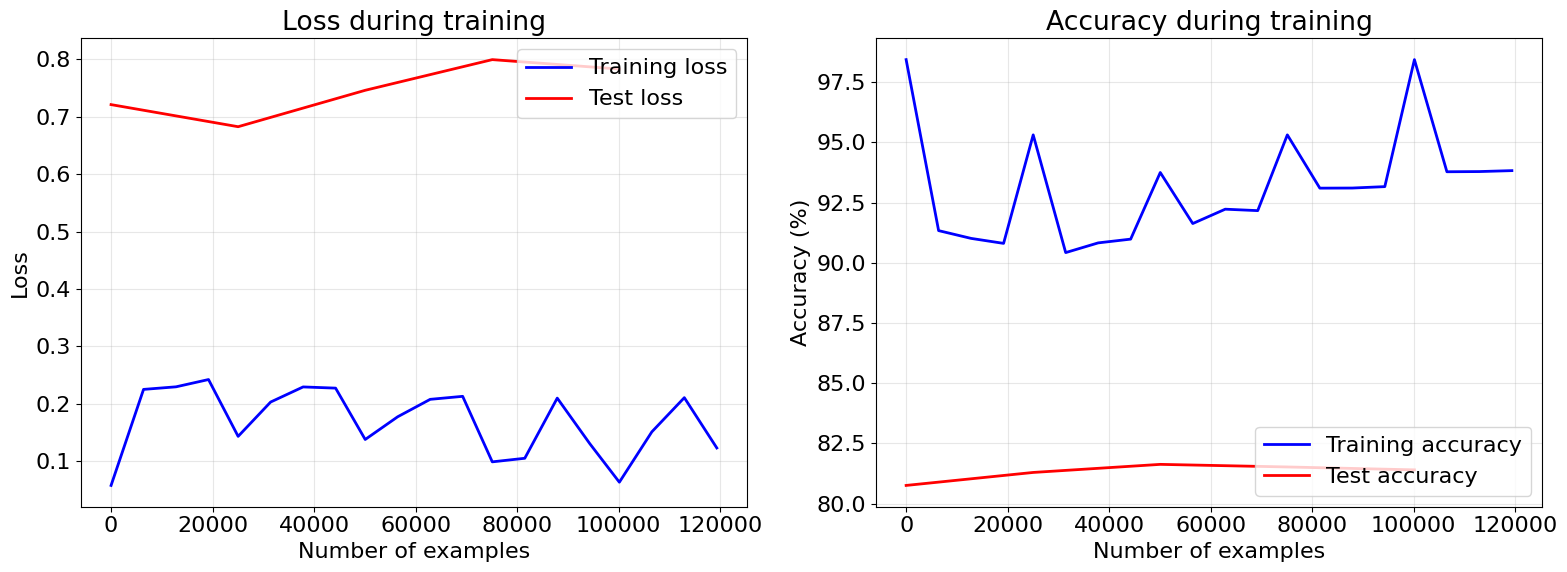

In [50]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

In [51]:
check_quantization_status(qat_model_MLP)
check_by_size_comparison_complete(fp32_model, qat_model_MLP)

visual_features.features.0: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 3, 3, 3])
visual_features.features.3.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 64, 1, 1])
visual_features.features.3.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.3.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.4.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 128, 1, 1])
visual_features.features.4.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.4.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.6.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([32, 128, 1, 1])
visual_features.features.6.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([128, 32, 1, 1])
visual_features.features.6.expand3x3: Conv2d | dtype: torch.float32 | shape: t

(172.0572452545166, 172.05547523498535, 0.0010287387367103832)

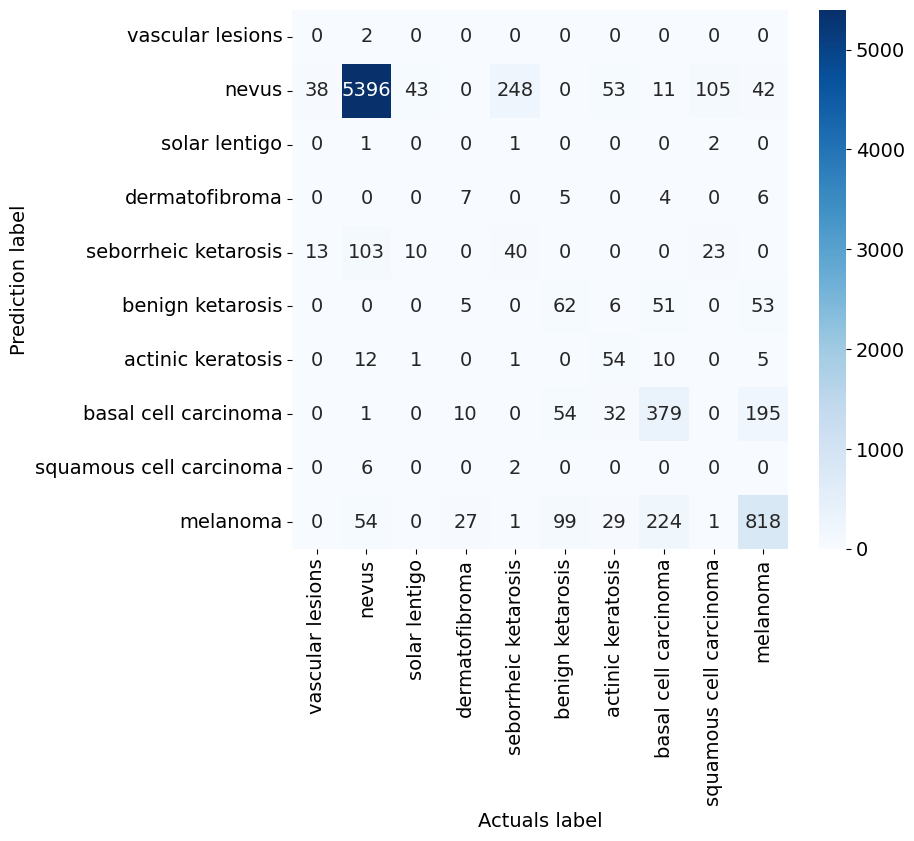

Sensitivity: 0.8096
Specificity: 0.9788
Precision: 0.8096
NPV: 0.9788
PPV: 0.8096
FNR: 0.1904
FPR: 0.0212
F1: 0.8096
Recall micro: 0.8096
Recall macro: 0.3129
Precision micro: 0.8096
Precision macro: 0.3657
F1 score micro: 0.8096
F1 score macro: 0.3284
Jaccard score micro: 0.6801
Jaccard score macro: 0.2450
Accuracy score: 0.8096
Matthews corrcoef: 0.6194
Specificity macro: 0.9667
Specificity micro: 0.9788
Specificity weighted: 0.8575
Specificity none - class vascular lesions (0): 0.9998
Specificity none - class nevus (1): 0.8051
Specificity none - class solar lentigo (2): 0.9995
Specificity none - class dermatofibroma (3): 0.9982
Specificity none - class seborrheic ketarosis (4): 0.9815
Specificity none - class benign ketarosis (5): 0.9858
Specificity none - class actinic keratosis (6): 0.9965
Specificity none - class basal cell carcinoma (7): 0.9619
Specificity none - class squamous cell carcinoma (8): 0.9990
Specificity none - class melanoma (9): 0.9398


In [52]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_MLP, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_MLP = test_metric()

In [53]:
class QuantizedClassifiers_QAT(nn.Module):
    def __init__(self, original_visual_classifier, original_combined_classifier):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.visual_classifier = original_visual_classifier
        self.combined_classifier = original_combined_classifier
        
    def forward(self, visual_features, metadata_features):
        visual_features = self.quant(visual_features)
        visual_out = self.visual_classifier(visual_features)
        visual_out = self.dequant(visual_out)
        
        combined_features = torch.cat((visual_out, metadata_features), dim=1)
        
        combined_features = self.quant(combined_features)
        output = self.combined_classifier(combined_features)
        output = self.dequant(output)
        
        return output

def QAT_quantize_classifiers_together(model):
    visual_features_state = model.visual_features.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    
    quantized_classifiers = QuantizedClassifiers_QAT(
        model.visual_classifier, 
        model.combined_classifier
    )
    quantized_classifiers = quantized_classifiers.to(device)
    quantized_classifiers.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

    model_prepared = prepare_qat(quantized_classifiers, inplace=False)
    

    class Multimodal_With_QuantizedClassifiers_QAT(nn.Module):
        def __init__(self, visual_features, metadata_net, quantized_classifiers):
            super().__init__()
            self.visual_features = visual_features
            self.metadata_net = metadata_net
            self.quantized_classifiers = quantized_classifiers
            
        def forward(self, image, metadata):
            visual_features = self.visual_features(image)
            visual_features = visual_features.reshape(visual_features.size(0), -1)
            
            metadata_features = self.metadata_net(metadata)

            output = self.quantized_classifiers(visual_features, metadata_features)
            return output

    final_model = Multimodal_With_QuantizedClassifiers_QAT(
        model.visual_features,
        model.metadata_net, 
        model_prepared
    )

    final_model.visual_features.load_state_dict(visual_features_state)
    final_model.metadata_net.load_state_dict(metadata_net_state)

    return final_model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_classifier = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_classifier.load_state_dict(fp32_model.state_dict())

qat_model_classifier = QAT_quantize_classifiers_together(qat_model_classifier)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_classifier.parameters(), lr=0.001, momentum=0.9)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cuda")
qat_model_classifier  = train_and_evaluate(qat_model_classifier, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_classifier')

device = torch.device("cpu")
qat_model_classifier .eval()
qat_model_classifier  = qat_model_classifier.to(device)
qat_model_classifier.quantized_classifiers = convert(qat_model_classifier.quantized_classifiers, inplace=False)

print(f"QAT мультимодальная модель qat_model_classifier на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Начало QAT с предобученными весами...
________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 0.1031	 | Точность распознавания: 93.75%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.2413	 | Точность распознавания: 91.46%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.2135	 | Точность распознавания: 91.36%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.3440	 | Точность распознавания: 90.84%

   Тренировочная ошибка: 0.2352 Точность: 22749/25035 (90.87%)
        Время обучения: 00:00:21

   Валидационная ошибка: 0.6661 Точность: 6755/8345 (80.95%)
        Время тестирования: 00:00:04

Лучшая валидационная точность: 0.8095
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.0822	 | Точность распознавания: 9

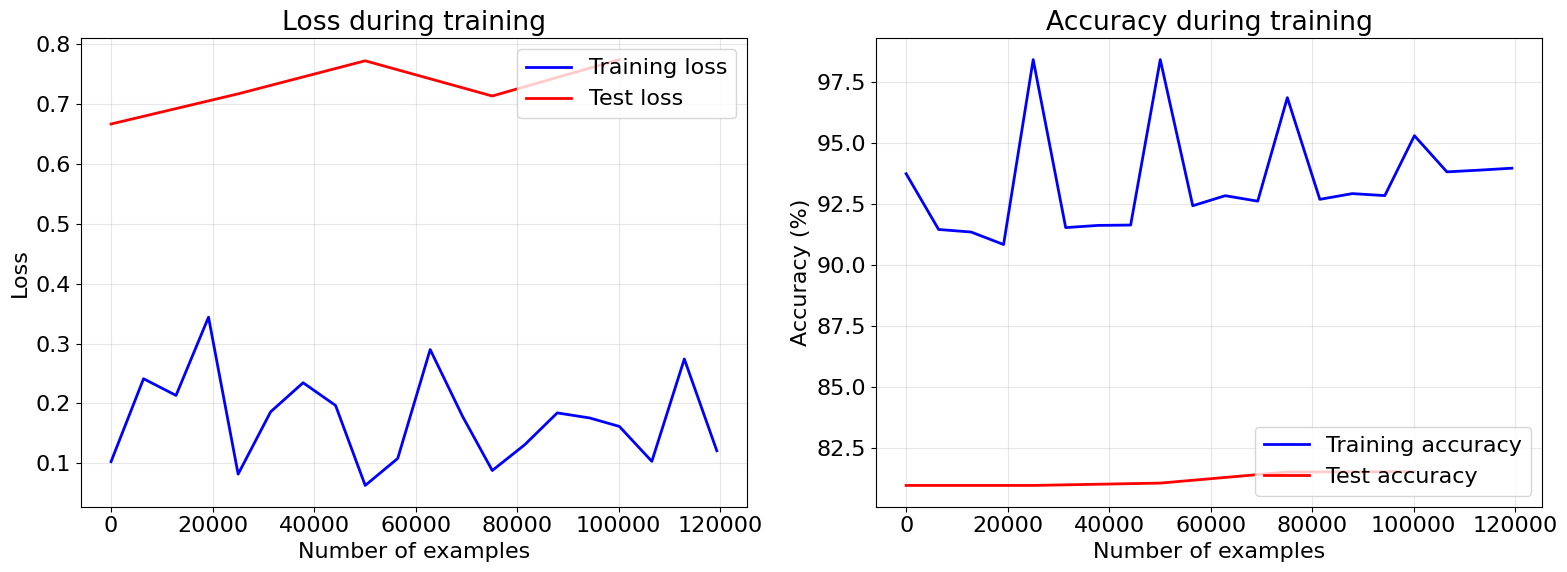

In [54]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

In [55]:
check_quantization_status(qat_model_classifier)
check_by_size_comparison_complete(fp32_model, qat_model_classifier)

visual_features.features.0: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 3, 3, 3])
visual_features.features.3.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 64, 1, 1])
visual_features.features.3.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.3.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.4.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([16, 128, 1, 1])
visual_features.features.4.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 1, 1])
visual_features.features.4.expand3x3: Conv2d | dtype: torch.float32 | shape: torch.Size([64, 16, 3, 3])
visual_features.features.6.squeeze: Conv2d | dtype: torch.float32 | shape: torch.Size([32, 128, 1, 1])
visual_features.features.6.expand1x1: Conv2d | dtype: torch.float32 | shape: torch.Size([128, 32, 1, 1])
visual_features.features.6.expand3x3: Conv2d | dtype: torch.float32 | shape: t

(172.0572452545166, 45.12312698364258, 73.77435229949548)

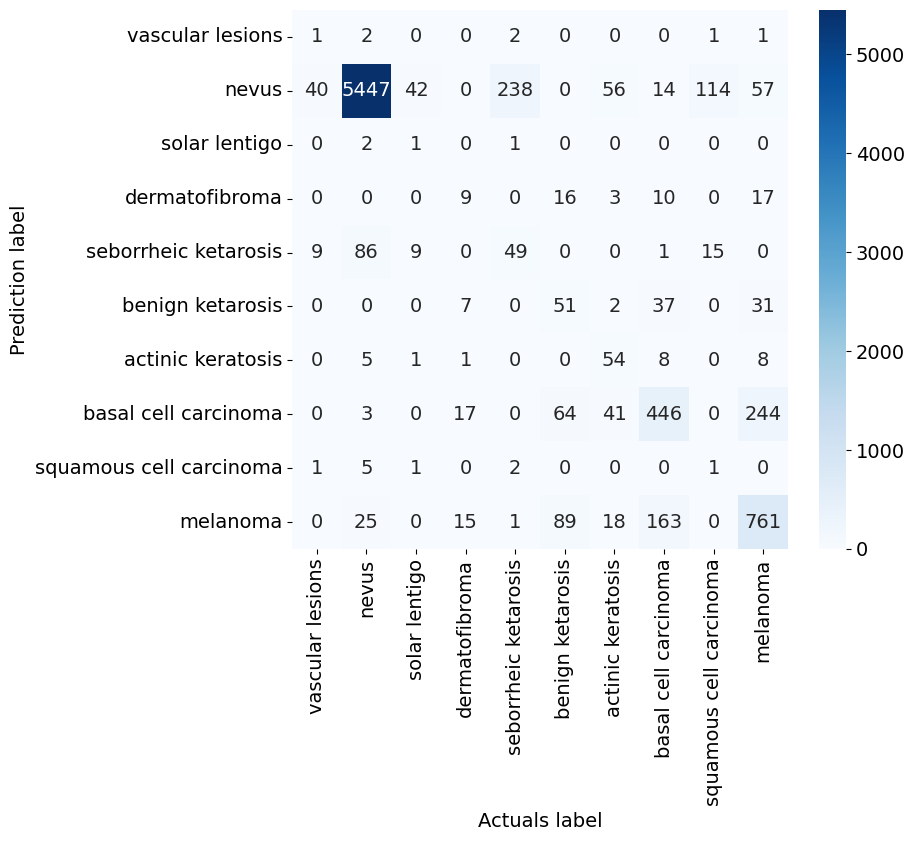

Sensitivity: 0.8173
Specificity: 0.9797
Precision: 0.8173
NPV: 0.9797
PPV: 0.8173
FNR: 0.1827
FPR: 0.0203
F1: 0.8173
Recall micro: 0.8173
Recall macro: 0.3253
Precision micro: 0.8173
Precision macro: 0.4210
F1 score micro: 0.8173
F1 score macro: 0.3424
Jaccard score micro: 0.6910
Jaccard score macro: 0.2547
Accuracy score: 0.8173
Matthews corrcoef: 0.6330
Specificity macro: 0.9671
Specificity micro: 0.9797
Specificity weighted: 0.8541
Specificity none - class vascular lesions (0): 0.9993
Specificity none - class nevus (1): 0.7975
Specificity none - class solar lentigo (2): 0.9996
Specificity none - class dermatofibroma (3): 0.9945
Specificity none - class seborrheic ketarosis (4): 0.9851
Specificity none - class benign ketarosis (5): 0.9905
Specificity none - class actinic keratosis (6): 0.9972
Specificity none - class basal cell carcinoma (7): 0.9519
Specificity none - class squamous cell carcinoma (8): 0.9989
Specificity none - class melanoma (9): 0.9570


In [56]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_classifier, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_classifier = test_metric()

In [57]:
class QuantizedMultimodal_QAT(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()

        self.visual_features = original_model.visual_features
        self.visual_classifier = original_model.visual_classifier
        self.metadata_net = original_model.metadata_net
        self.combined_classifier = original_model.combined_classifier
        
    def forward(self, image, metadata):
        image = self.quant(image)
        metadata = self.quant(metadata)

        visual_feat = self.visual_features(image)
        visual_feat = visual_feat.view(visual_feat.size(0), -1)
        visual_out = self.visual_classifier(visual_feat)
        
        metadata_out = self.metadata_net(metadata)

        visual_out = self.dequant(visual_out)
        metadata_out = self.dequant(metadata_out)
        
        combined = torch.cat((visual_out, metadata_out), dim=1)

        combined = self.quant(combined)
        output = self.combined_classifier(combined)
        output = self.dequant(output)
        
        return output

def QAT_quantize_completely_simple(model):
    
    quant_model = QuantizedMultimodal_QAT(model)
    quant_model = quant_model.to(device)

    quant_model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

    model_prepared = prepare_qat(quant_model, inplace=False)
    
    return model_prepared

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_full = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_full.load_state_dict(fp32_model.state_dict())

qat_model_full = QAT_quantize_completely_simple(qat_model_full)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_full.parameters(), lr=0.001, momentum=0.9)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cuda")
qat_model_full  = train_and_evaluate(qat_model_full, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_full')

device = torch.device("cpu")
qat_model_full.eval()
qat_model_full  = qat_model_full.to(device)
qat_model_full = convert(qat_model_full, inplace=False)

print(f"QAT мультимодальная модель qat_model_full на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Начало QAT с предобученными весами...
________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 0.4039	 | Точность распознавания: 89.06%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.2441	 | Точность распознавания: 89.14%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.3264	 | Точность распознавания: 88.60%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.2892	 | Точность распознавания: 88.17%

   Тренировочная ошибка: 0.3164 Точность: 22076/25035 (88.18%)
        Время обучения: 00:00:26

   Валидационная ошибка: 0.5986 Точность: 6770/8345 (81.13%)
        Время тестирования: 00:00:05

Лучшая валидационная точность: 0.8113
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.2899	 | Точность распознавания: 8

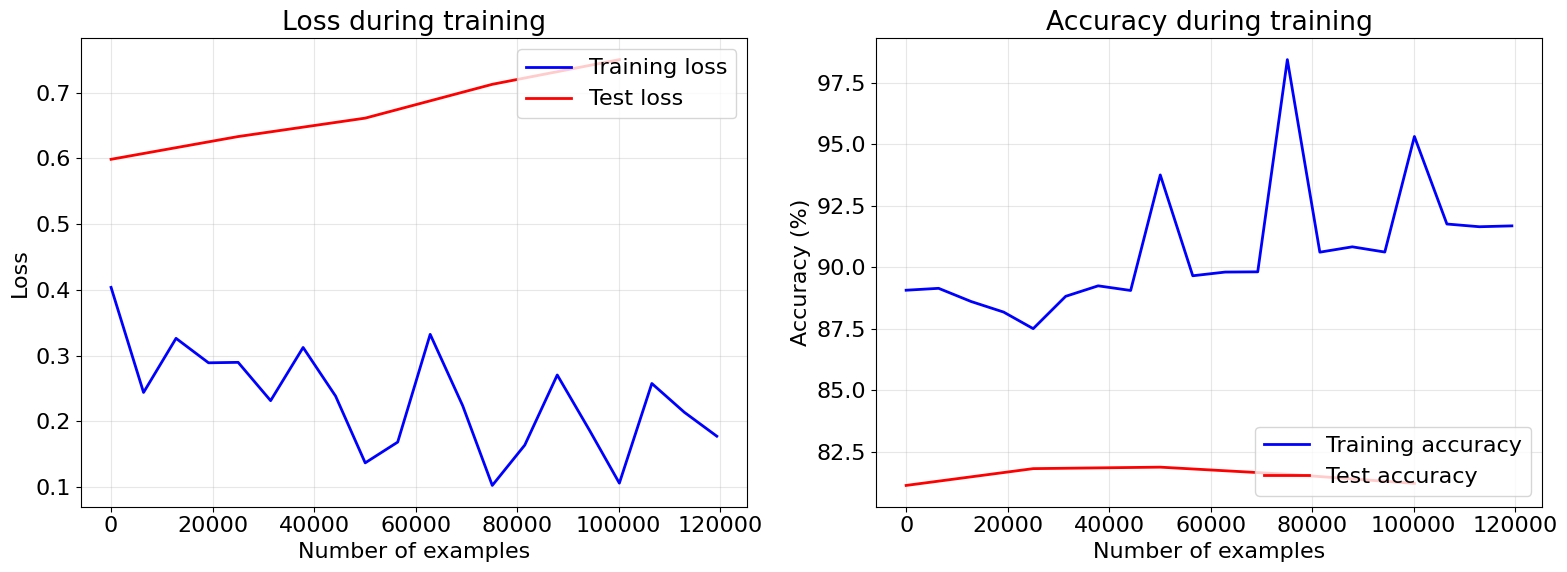

In [58]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

In [59]:
check_quantization_status(qat_model_full)
check_by_size_comparison_complete(fp32_model, qat_model_full)

visual_features.features.0: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.3.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.4.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.6.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.7.expand3x3: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.squeeze: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.expand1x1: Conv2d | КВАНТОВАННЫЙ СЛОЙ
visual_features.features.9.expand3x3: Conv2d 

(172.0572452545166, 43.13621520996094, 74.92914922231176)

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

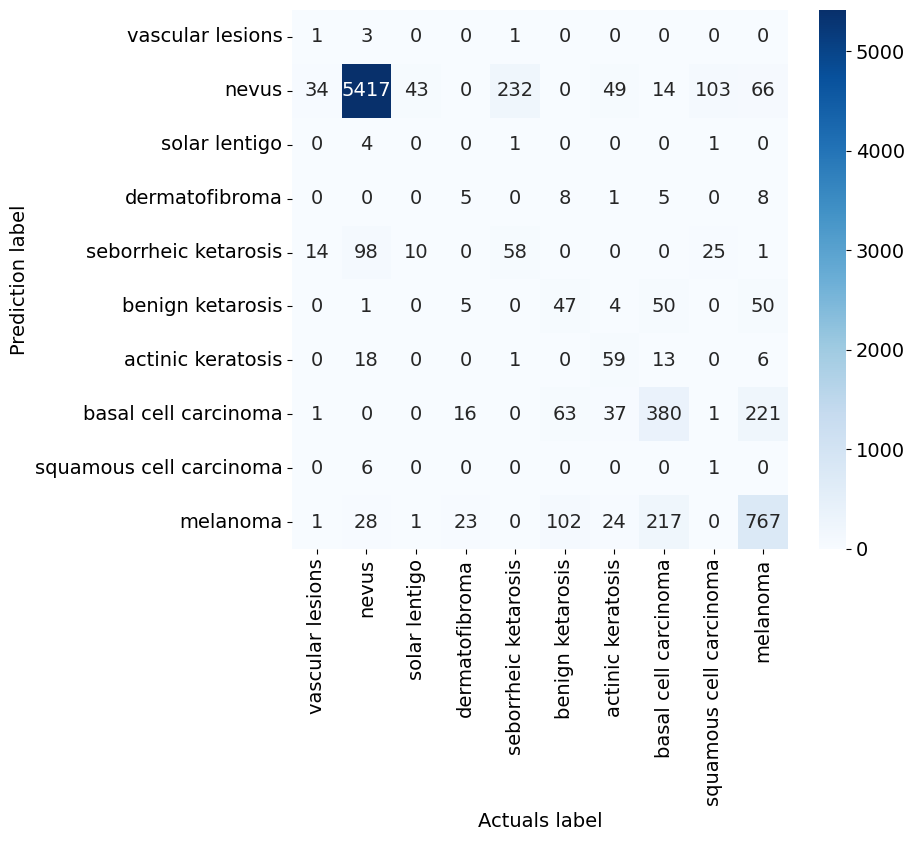

Sensitivity: 0.8071
Specificity: 0.9786
Precision: 0.8071
NPV: 0.9786
PPV: 0.8071
FNR: 0.1929
FPR: 0.0214
F1: 0.8071
Recall micro: 0.8071
Recall macro: 0.3097
Precision micro: 0.8071
Precision macro: 0.3814
F1 score micro: 0.8071
F1 score macro: 0.3254
Jaccard score micro: 0.6765
Jaccard score macro: 0.2413
Accuracy score: 0.8071
Matthews corrcoef: 0.6137
Specificity macro: 0.9665
Specificity micro: 0.9786
Specificity weighted: 0.8574
Specificity none - class vascular lesions (0): 0.9995
Specificity none - class nevus (1): 0.8047
Specificity none - class solar lentigo (2): 0.9993
Specificity none - class dermatofibroma (3): 0.9973
Specificity none - class seborrheic ketarosis (4): 0.9816
Specificity none - class benign ketarosis (5): 0.9865
Specificity none - class actinic keratosis (6): 0.9953
Specificity none - class basal cell carcinoma (7): 0.9558
Specificity none - class squamous cell carcinoma (8): 0.9993
Specificity none - class melanoma (9): 0.9452


In [60]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_full, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_full = test_metric()

In [61]:
def find_all_models():
    """Находит все экземпляры nn.Module в глобальной области видимости"""
    import torch.nn as nn
    models = {}
    
    for var_name, var_value in globals().items():
        if isinstance(var_value, nn.Module):
            models[var_name] = {
                'type': type(var_value).__name__,
                #'device': next(var_value.parameters()).device if any(var_value.parameters()) else 'no parameters',
                'parameters': sum(p.numel() for p in var_value.parameters()),
                'size_mb': sum(p.numel() * p.element_size() for p in var_value.parameters()) / (1024 * 1024)
            }
    
    return models

# Использование:
all_models = find_all_models()
print("🎯 НАЙДЕННЫЕ МОДЕЛИ:")
for name, info in all_models.items():
    print(f"  {name}: {info['type']} | Параметров: {info['parameters']:,} | Размер: {info['size_mb']:.2f} МБ")

🎯 НАЙДЕННЫЕ МОДЕЛИ:
  original_NN: SqueezeNet | Параметров: 1,235,496 | Размер: 4.71 МБ
  _2: SqueezeNet | Параметров: 1,235,496 | Размер: 4.71 МБ
  fp32_model: Multimodal_NN | Параметров: 45,097,210 | Размер: 172.03 МБ
  criterion: CrossEntropyLoss | Параметров: 0 | Размер: 0.00 МБ
  ptq_model_CNN: Multimodal_NN | Параметров: 44,374,714 | Размер: 169.28 МБ
  ptq_model_model_quantized_CNN: Multimodal_NN | Параметров: 44,374,714 | Размер: 169.28 МБ
  ptq_model_MLP: Multimodal_NN | Параметров: 45,094,346 | Размер: 172.02 МБ
  ptq_model_model_quantized_MLP: Multimodal_NN | Параметров: 45,094,346 | Размер: 172.02 МБ
  ptq_model_linear: Multimodal_NN | Параметров: 45,097,210 | Размер: 172.03 МБ
  ptq_model_model_quantized_linear: Multimodal_With_QuantizedClassifiers | Параметров: 725,360 | Размер: 2.77 МБ
  ptq_model_full: Multimodal_NN | Параметров: 45,097,210 | Размер: 172.03 МБ
  ptq_model_model_quantized_full: QuantizedMultimodal | Параметров: 0 | Размер: 0.00 МБ
  qat_model_CNN: Multim

In [62]:
print(f"Точность FP32 {model_name}: {fp32_final_acc:.2f}%")
print("_" * 60)

print(f"Точность PTQ_CNN {model_name}: {ptq_accuracy_CNN:.2f}%")
print(f"Точность PTQ_MLP {model_name}: {ptq_accuracy_MLP:.2f}%")
print(f"Точность PTQ_classif {model_name}: {ptq_accuracy_linear:.2f}%")
print(f"Точность PTQ_full {model_name}: {ptq_accuracy_full:.2f}%")
print("_" * 60)

print(f"Точность QAT_CNN {model_name}: {qat_accuracy_CNN:.2f}%")
print(f"Точность QAT_MLP {model_name}: {qat_accuracy_MLP:.2f}%")
print(f"Точность QAT_classif {model_name}: {qat_accuracy_classifier:.2f}%")
print(f"Точность QAT_full {model_name}: {qat_accuracy_full:.2f}%")
print("_" * 60)

#print(f"\nПотеря точности PTQ: {fp32_final_acc - ptq_accuracy_full:.2f}%")
#print(f"Потеря точности QAT: {fp32_final_acc - qat_accuracy_full:.2f}%")

Точность FP32 squeezenet1_1: 82.16%
____________________________________________________________
Точность PTQ_CNN squeezenet1_1: 81.86%
Точность PTQ_MLP squeezenet1_1: 82.14%
Точность PTQ_classif squeezenet1_1: 81.98%
Точность PTQ_full squeezenet1_1: 77.94%
____________________________________________________________
Точность QAT_CNN squeezenet1_1: 80.85%
Точность QAT_MLP squeezenet1_1: 80.96%
Точность QAT_classif squeezenet1_1: 81.73%
Точность QAT_full squeezenet1_1: 80.71%
____________________________________________________________


In [63]:
torch.save(fp32_model.state_dict(), "multimodal_fp32.pth")
fp32_size = os.path.getsize("multimodal_fp32.pth")
print(f"Размер FP32 оригинальной модели: {fp32_size / 1024 / 1024:.2f} MB")
print()

# PTQ модели
print("🎯 PTQ МОДЕЛИ:")
print("-" * 50)

# PTQ AlexNet
torch.save(ptq_model_model_quantized_CNN.state_dict(), "multimodal_ptq_alexnet.pth")
ptq_alexnet_size = os.path.getsize("multimodal_ptq_alexnet.pth")
print(f"PTQ AlexNet: {ptq_alexnet_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / ptq_alexnet_size:.2f}x")

# PTQ MLP
torch.save(ptq_model_model_quantized_MLP.state_dict(), "multimodal_ptq_mlp.pth")
ptq_mlp_size = os.path.getsize("multimodal_ptq_mlp.pth")
print(f"PTQ MLP:     {ptq_mlp_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / ptq_mlp_size:.2f}x")

# PTQ Classifiers
torch.save(ptq_model_model_quantized_linear.state_dict(), "multimodal_ptq_classifiers.pth")
ptq_classifiers_size = os.path.getsize("multimodal_ptq_classifiers.pth")
print(f"PTQ Classifiers: {ptq_classifiers_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / ptq_classifiers_size:.2f}x")

# PTQ Full
torch.save(ptq_model_model_quantized_full.state_dict(), "multimodal_ptq_full.pth")
ptq_full_size = os.path.getsize("multimodal_ptq_full.pth")
print(f"PTQ Full:    {ptq_full_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / ptq_full_size:.2f}x")

print()
print("🎯 QAT МОДЕЛИ:")
print("-" * 50)

# QAT AlexNet
torch.save(qat_model_CNN.state_dict(), "multimodal_qat_alexnet.pth")
qat_alexnet_size = os.path.getsize("multimodal_qat_alexnet.pth")
print(f"QAT AlexNet: {qat_alexnet_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / qat_alexnet_size:.2f}x")

# QAT MLP
torch.save(qat_model_MLP.state_dict(), "multimodal_qat_mlp.pth")
qat_mlp_size = os.path.getsize("multimodal_qat_mlp.pth")
print(f"QAT MLP:     {qat_mlp_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / qat_mlp_size:.2f}x")

# QAT Classifiers
torch.save(qat_model_classifier.state_dict(), "multimodal_qat_classifiers.pth")
qat_classifiers_size = os.path.getsize("multimodal_qat_classifiers.pth")
print(f"QAT Classifiers: {qat_classifiers_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / qat_classifiers_size:.2f}x")

# QAT Full
torch.save(qat_model_full.state_dict(), "multimodal_qat_full.pth")
qat_full_size = os.path.getsize("multimodal_qat_full.pth")
print(f"QAT Full:    {qat_full_size / 1024 / 1024:.2f} MB | Сжатие: {fp32_size / qat_full_size:.2f}x")

Размер FP32 оригинальной модели: 172.06 MB

🎯 PTQ МОДЕЛИ:
--------------------------------------------------
PTQ AlexNet: 170.07 MB | Сжатие: 1.01x
PTQ MLP:     172.05 MB | Сжатие: 1.00x
PTQ Classifiers: 45.12 MB | Сжатие: 3.81x
PTQ Full:    43.14 MB | Сжатие: 3.99x

🎯 QAT МОДЕЛИ:
--------------------------------------------------
QAT AlexNet: 170.07 MB | Сжатие: 1.01x
QAT MLP:     172.05 MB | Сжатие: 1.00x
QAT Classifiers: 45.12 MB | Сжатие: 3.81x
QAT Full:    43.14 MB | Сжатие: 3.99x


In [64]:
def create_comprehensive_report():
    """Создает комплексный отчет по всем моделям"""
    
    # Собираем все данные точности
    accuracy_data = {
        'FP32': fp32_final_acc,
        'PTQ_CNN': ptq_accuracy_CNN,
        'PTQ_MLP': ptq_accuracy_MLP,
        'PTQ_classif': ptq_accuracy_linear,
        'PTQ_full': ptq_accuracy_full,
        'QAT_CNN': qat_accuracy_CNN,
        'QAT_MLP': qat_accuracy_MLP,
        'QAT_classif': qat_accuracy_classifier,
        'QAT_full': qat_accuracy_full
    }
    
    # Получаем размеры моделей
    size_data = get_model_sizes()
    
    # Получаем данные скорости
    speed_data = get_model_speeds()
    
    # Создаем визуализацию
    create_comprehensive_visualization(accuracy_data, size_data, speed_data)
    
    return accuracy_data, size_data, speed_data

def get_model_sizes():
    """Получает размеры всех моделей"""
    models = {
        'FP32': fp32_model,
        'PTQ_CNN': ptq_model_model_quantized_CNN,
        'PTQ_MLP': ptq_model_model_quantized_MLP,
        'PTQ_classif': ptq_model_model_quantized_linear,
        'PTQ_full': ptq_model_model_quantized_full,
        'QAT_CNN': qat_model_CNN,
        'QAT_MLP': qat_model_MLP,
        'QAT_classif': qat_model_classifier,
        'QAT_full': qat_model_full
    }
    
    sizes = {}
    for name, model in models.items():
        torch.save(model.state_dict(), f"temp_{name}.pth")
        size_bytes = os.path.getsize(f"temp_{name}.pth")
        sizes[name] = size_bytes / 1024 / 1024  # Convert to MB
        os.remove(f"temp_{name}.pth")
    
    return sizes

def get_model_speeds():
    """Получает данные о скорости всех моделей"""
    # Запускаем бенчмарки если еще не сделано
    fp32_avg, ptq_results, qat_results = run_all_benchmarks()
    
    speeds = {'FP32': 1.0}  # Базовое значение
    
    # PTQ скорости
    for name, (total, avg) in ptq_results.items():
        speeds[f'PTQ_{name}'] = fp32_avg / avg
    
    # QAT скорости
    for name, (total, avg) in qat_results.items():
        speeds[f'QAT_{name}'] = fp32_avg / avg
    
    return speeds

def benchmark_model(model, test_loader, model_name, num_batches=20):
    device = torch.device("cpu")
    model = model.to(device).eval()
    
    # Теплый запуск
    with torch.no_grad():
        for inputs, feats, label, name in test_loader:
            inputs = inputs.to(device)
            feats = feats.to(device)
            _ = model(inputs, feats)
            break
    
    # Бенчмарк
    start_time = time.time()
    with torch.no_grad():
        for i, (inputs, feats, label, name) in enumerate(test_loader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            feats = feats.to(device)
            _ = model(inputs, feats)
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_time_per_batch = total_time / num_batches
    return total_time, avg_time_per_batch

def run_all_benchmarks():
    """Запускает бенчмарки для всех моделей"""
    
    print("🚀 ЗАПУСК БЕНЧМАРКОВ ВСЕХ МОДЕЛЕЙ")
    print("_" * 70)
    
    # Бенчмарк FP32 модели
    print("🔵 Бенчмарк FP32 оригинальной модели...")
    fp32_total, fp32_avg = benchmark_model(fp32_model, testloader, "FP32 Original")
    
    # PTQ модели
    print("\n🎯 PTQ МОДЕЛИ:")
    print("-" * 50)
    
    ptq_results = {}
    
    print("Бенчмарк PTQ AlexNet...")
    ptq_alexnet_total, ptq_alexnet_avg = benchmark_model(ptq_model_model_quantized_CNN, testloader, "PTQ AlexNet")
    ptq_results['alexnet'] = (ptq_alexnet_total, ptq_alexnet_avg)
    
    print("Бенчмарк PTQ MLP...")
    ptq_mlp_total, ptq_mlp_avg = benchmark_model(ptq_model_model_quantized_MLP, testloader, "PTQ MLP")
    ptq_results['mlp'] = (ptq_mlp_total, ptq_mlp_avg)
    
    print("Бенчмарк PTQ Classifiers...")
    ptq_classifiers_total, ptq_classifiers_avg = benchmark_model(ptq_model_model_quantized_linear, testloader, "PTQ Classifiers")
    ptq_results['classifiers'] = (ptq_classifiers_total, ptq_classifiers_avg)
    
    print("Бенчмарк PTQ Full...")
    ptq_full_total, ptq_full_avg = benchmark_model(ptq_model_model_quantized_full, testloader, "PTQ Full")
    ptq_results['full'] = (ptq_full_total, ptq_full_avg)
    
    # QAT модели
    print("\n🎯 QAT МОДЕЛИ:")
    print("-" * 50)
    
    qat_results = {}
    
    print("Бенчмарк QAT AlexNet...")
    qat_alexnet_total, qat_alexnet_avg = benchmark_model(qat_model_CNN, testloader, "QAT AlexNet")
    qat_results['alexnet'] = (qat_alexnet_total, qat_alexnet_avg)
    
    print("Бенчмарк QAT MLP...")
    qat_mlp_total, qat_mlp_avg = benchmark_model(qat_model_MLP, testloader, "QAT MLP")
    qat_results['mlp'] = (qat_mlp_total, qat_mlp_avg)
    
    print("Бенчмарк QAT Classifiers...")
    qat_classifiers_total, qat_classifiers_avg = benchmark_model(qat_model_classifier, testloader, "QAT Classifiers")
    qat_results['classifiers'] = (qat_classifiers_total, qat_classifiers_avg)
    
    print("Бенчмарк QAT Full...")
    qat_full_total, qat_full_avg = benchmark_model(qat_model_full, testloader, "QAT Full")
    qat_results['full'] = (qat_full_total, qat_full_avg)
    
    # Вывод результатов
    print_results(fp32_avg, ptq_results, qat_results)
    
    return fp32_avg, ptq_results, qat_results

def print_results(fp32_avg, ptq_results, qat_results):
    """Красивый вывод результатов"""
    
    print("\n" + "_" * 80)
    print("📊 РЕЗУЛЬТАТЫ СКОРОСТИ (CPU)")
    print("_" * 80)
    print(f"{'Модель':<25} {'Время батча':<12} {'Ускорение':<10} {'Статус':<15}")
    print("-" * 80)
    
    print(f"{'FP32 Original':<25} {fp32_avg:>8.4f}s    {'-':<10}    {'Базовый':<15}")
    
    # PTQ результаты
    for name, (total, avg) in ptq_results.items():
        speedup = fp32_avg / avg
        status = "🚀 ОТЛИЧНО" if speedup > 1.5 else "✅ ХОРОШО" if speedup > 1.1 else "⚠️ НОРМА"
        print(f"{'PTQ ' + name.capitalize():<25} {avg:>8.4f}s    {speedup:>7.2f}x    {status:<15}")
    
    # QAT результаты  
    for name, (total, avg) in qat_results.items():
        speedup = fp32_avg / avg
        status = "🚀 ОТЛИЧНО" if speedup > 1.5 else "✅ ХОРОШО" if speedup > 1.1 else "⚠️ НОРМА"
        print(f"{'QAT ' + name.capitalize():<25} {avg:>8.4f}s    {speedup:>7.2f}x    {status:<15}")
    
    print("=" * 80)
    
    # Находим лучшие модели
    best_ptq = max(ptq_results.items(), key=lambda x: fp32_avg / x[1][1])
    best_qat = max(qat_results.items(), key=lambda x: fp32_avg / x[1][1])
    
    print(f"\n🏆 Лучшее PTQ ускорение: {best_ptq[0]} - {fp32_avg / best_ptq[1][1]:.2f}x")
    print(f"🏆 Лучшее QAT ускорение: {best_qat[0]} - {fp32_avg / best_qat[1][1]:.2f}x")

In [65]:
def create_comprehensive_visualization(accuracy_data, size_data, speed_data):
    
    # Подготовка данных
    models = list(accuracy_data.keys())
    accuracies = list(accuracy_data.values())
    sizes = [size_data.get(model, 0) for model in models]
    speeds = [speed_data.get(model, 1.0) for model in models]
    
    # Цвета для разных типов моделей
    colors = []
    for model in models:
        if model == 'FP32':
            colors.append('blue')
        elif model.startswith('PTQ'):
            colors.append('red')
        else:  # QAT
            colors.append('green')
    
    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
    plt.rcParams['font.size'] = 12
    
    # 1. График точности
    bars1 = ax1.bar(models, accuracies, color=colors, alpha=0.8)
    ax1.set_title('Сравнение точности всех моделей', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Точность (%)', fontsize=14)
    ax1.set_ylim(0, max(accuracies) + 5)
    ax1.tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars1, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # 2. График размеров
    bars2 = ax2.bar(models, sizes, color=colors, alpha=0.8)
    ax2.set_title('Сравнение размеров моделей', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Размер (MB)', fontsize=14)
    ax2.tick_params(axis='x', rotation=45)
    for bar, size in zip(bars2, sizes):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{size:.2f}MB', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # 3. График скорости
    bars3 = ax3.bar(models, speeds, color=colors, alpha=0.8)
    ax3.set_title('Относительная скорость моделей', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Ускорение (x)', fontsize=14)
    ax3.tick_params(axis='x', rotation=45)
    for bar, speed in zip(bars3, speeds):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{speed:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # 4. Сводная таблица
    ax4.axis('tight')
    ax4.axis('off')
    
    # Подготовка данных для таблицы
    table_data = []
    for model in models:
        table_data.append([
            f"{accuracy_data.get(model, 0):.2f}%",
            f"{size_data.get(model, 0):.1f} MB",
            f"{speed_data.get(model, 1.0):.2f}x"
        ])
    
    table = ax4.table(
        cellText=table_data,
        rowLabels=models,
        colLabels=['Точность', 'Размер', 'Ускорение'],
        cellLoc='center',
        loc='center',
        colWidths=[0.3, 0.3, 0.3]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax4.set_title('Сводная таблица всех моделей', fontsize=16, fontweight='bold')
    
    # Легенда
    legend_elements = [
        plt.Rectangle((0,0), 1, 1, facecolor='blue', alpha=0.8, label='FP32'),
        plt.Rectangle((0,0), 1, 1, facecolor='red', alpha=0.8, label='PTQ'),
        plt.Rectangle((0,0), 1, 1, facecolor='green', alpha=0.8, label='QAT')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
               ncol=3, fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.show()
    
    # Вывод статистики
    print_statistics(accuracy_data, size_data, speed_data)

In [66]:
def print_statistics(accuracy_data, size_data, speed_data):
    """Выводит статистику по всем моделям"""
    
    print("_" * 80)
    print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ МОДЕЛЕЙ")
    print("_" * 80)
    
    # Лучшие модели по каждому показателю
    best_accuracy = max(accuracy_data.items(), key=lambda x: x[1])
    best_compression = max(size_data.items(), key=lambda x: size_data['FP32'] / x[1])
    best_speed = max(speed_data.items(), key=lambda x: x[1])
    
    print(f"🏆 Лучшая точность: {best_accuracy[0]} - {best_accuracy[1]:.2f}%")
    print(f"🏆 Лучшее сжатие: {best_compression[0]} - {size_data['FP32']/best_compression[1]:.2f}x")
    print(f"🏆 Лучшая скорость: {best_speed[0]} - {best_speed[1]:.2f}x")
    print()
    
    # Сравнение PTQ vs QAT
    ptq_models = {k: v for k, v in accuracy_data.items() if k.startswith('PTQ')}
    qat_models = {k: v for k, v in accuracy_data.items() if k.startswith('QAT')}
    
    if ptq_models and qat_models:
        avg_ptq_accuracy = sum(ptq_models.values()) / len(ptq_models)
        avg_qat_accuracy = sum(qat_models.values()) / len(qat_models)
        
        print("📈 СРЕДНИЕ ПОКАЗАТЕЛИ:")
        print(f"  PTQ модели: {avg_ptq_accuracy:.2f}% точность")
        print(f"  QAT модели: {avg_qat_accuracy:.2f}% точность")
        
        if avg_qat_accuracy > avg_ptq_accuracy:
            print(f"  ✅ QAT показывает лучшую среднюю точность на {avg_qat_accuracy - avg_ptq_accuracy:.2f}%")
        else:
            print(f"  ⚠️ PTQ показывает лучшую среднюю точность на {avg_ptq_accuracy - avg_qat_accuracy:.2f}%")
    
    print("\n🎯 РЕКОМЕНДАЦИИ:")
    
    # Рекомендации на основе данных
    if accuracy_data.get('PTQ_full', 0) > 95 and speed_data.get('PTQ_full', 0) > 1.5:
        print("  ✅ PTQ Full - оптимальный выбор: высокая точность и скорость")
    elif accuracy_data.get('QAT_full', 0) > accuracy_data.get('PTQ_full', 0):
        print("  ✅ QAT Full - лучшая точность при полном квантовании")
    else:
        print("  ✅ PTQ Full - лучший баланс точности и производительности")
    
    if size_data['FP32'] / size_data.get('PTQ_full', 1) > 3.5:
        print("  ✅ Отличное сжатие моделей (более 3.5x)")

🎯 КОМПЛЕКСНЫЙ ОТЧЕТ ПО ВСЕМ МОДЕЛЯМ
____________________________________________________________
Точность FP32: 82.16%
____________________________________________________________
Точность PTQ_CNN: 81.86%
Точность PTQ_MLP: 82.14%
Точность PTQ_classif: 81.98%
Точность PTQ_full: 77.94%
____________________________________________________________
Точность QAT_CNN: 80.85%
Точность QAT_MLP: 80.96%
Точность QAT_classif: 81.73%
Точность QAT_full: 80.71%
____________________________________________________________
🚀 ЗАПУСК БЕНЧМАРКОВ ВСЕХ МОДЕЛЕЙ
______________________________________________________________________
🔵 Бенчмарк FP32 оригинальной модели...

🎯 PTQ МОДЕЛИ:
--------------------------------------------------
Бенчмарк PTQ AlexNet...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

Бенчмарк PTQ MLP...
Бенчмарк PTQ Classifiers...
Бенчмарк PTQ Full...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 


🎯 QAT МОДЕЛИ:
--------------------------------------------------
Бенчмарк QAT AlexNet...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 

Бенчмарк QAT MLP...
Бенчмарк QAT Classifiers...
Бенчмарк QAT Full...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  return torch.cat(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\squeezenet.py:31: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies 


________________________________________________________________________________
📊 РЕЗУЛЬТАТЫ СКОРОСТИ (CPU)
________________________________________________________________________________
Модель                    Время батча  Ускорение  Статус         
--------------------------------------------------------------------------------
FP32 Original               0.1626s    -             Базовый        
PTQ Alexnet                 0.0715s       2.27x    🚀 ОТЛИЧНО      
PTQ Mlp                     0.1687s       0.96x    ⚠️ НОРМА       
PTQ Classifiers             0.1618s       1.00x    ⚠️ НОРМА       
PTQ Full                    0.0693s       2.35x    🚀 ОТЛИЧНО      
QAT Alexnet                 0.0700s       2.32x    🚀 ОТЛИЧНО      
QAT Mlp                     0.1632s       1.00x    ⚠️ НОРМА       
QAT Classifiers             0.1622s       1.00x    ⚠️ НОРМА       
QAT Full                    0.0706s       2.30x    🚀 ОТЛИЧНО      

🏆 Лучшее PTQ ускорение: full - 2.35x
🏆 Лучшее QAT ускоре

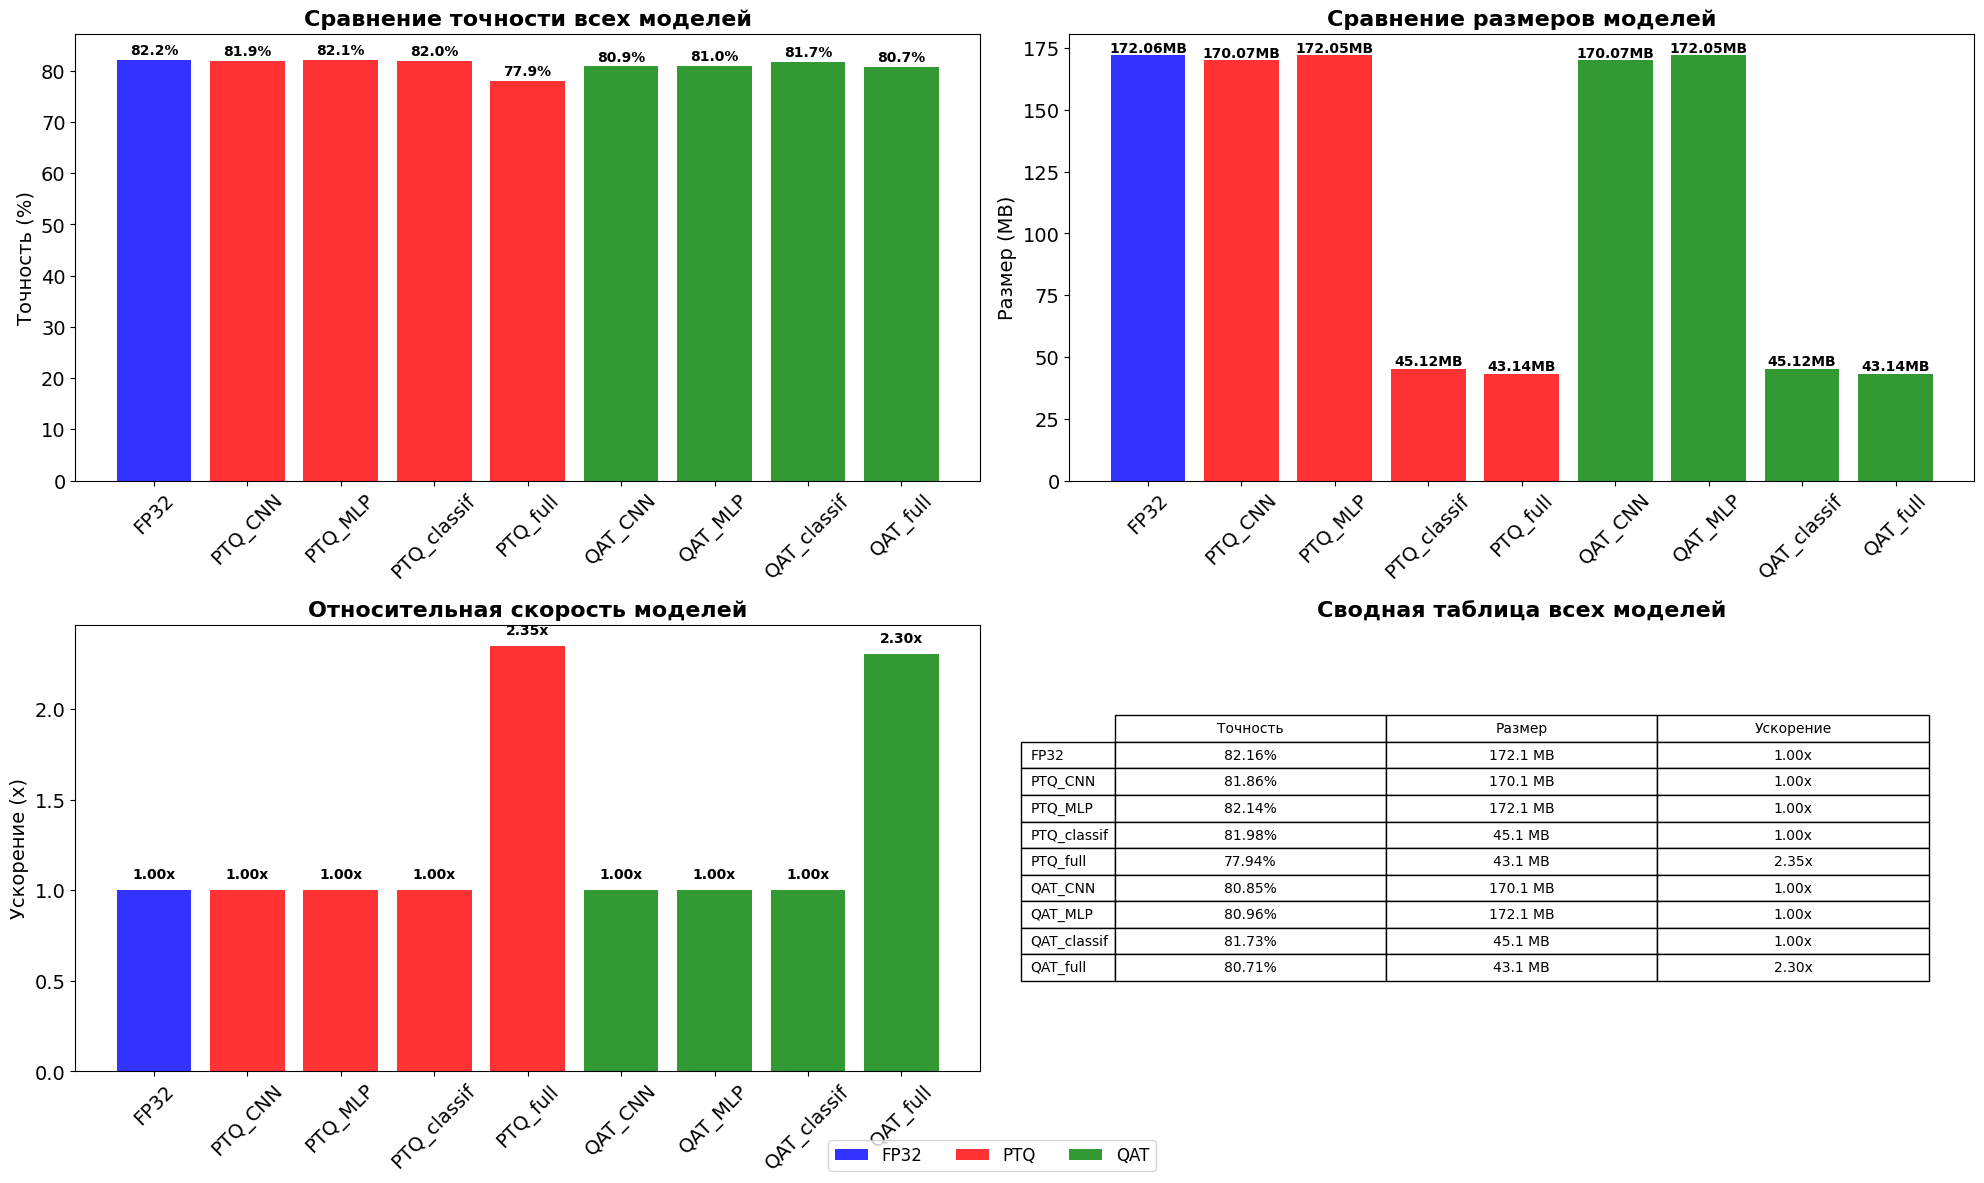

________________________________________________________________________________
📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ МОДЕЛЕЙ
________________________________________________________________________________
🏆 Лучшая точность: FP32 - 82.16%
🏆 Лучшее сжатие: PTQ_full - 3.99x
🏆 Лучшая скорость: PTQ_full - 2.35x

📈 СРЕДНИЕ ПОКАЗАТЕЛИ:
  PTQ модели: 80.98% точность
  QAT модели: 81.06% точность
  ✅ QAT показывает лучшую среднюю точность на 0.08%

🎯 РЕКОМЕНДАЦИИ:
  ✅ QAT Full - лучшая точность при полном квантовании
  ✅ Отличное сжатие моделей (более 3.5x)


In [68]:
# Запускаем полный отчет
print("🎯 КОМПЛЕКСНЫЙ ОТЧЕТ ПО ВСЕМ МОДЕЛЯМ")
print("_" * 60)

# Выводим исходные данные точности
print(f"Точность FP32: {fp32_final_acc:.2f}%")
print("_" * 60)

print(f"Точность PTQ_CNN: {ptq_accuracy_CNN:.2f}%")
print(f"Точность PTQ_MLP: {ptq_accuracy_MLP:.2f}%")
print(f"Точность PTQ_classif: {ptq_accuracy_linear:.2f}%")
print(f"Точность PTQ_full: {ptq_accuracy_full:.2f}%")
print("_" * 60)

print(f"Точность QAT_CNN: {qat_accuracy_CNN:.2f}%")
print(f"Точность QAT_MLP: {qat_accuracy_MLP:.2f}%")
print(f"Точность QAT_classif: {qat_accuracy_classifier:.2f}%")
print(f"Точность QAT_full: {qat_accuracy_full:.2f}%")
print("_" * 60)

# Создаем визуализацию
accuracy_data, size_data, speed_data = create_comprehensive_report()